# 06 - The gear train seen from both ends

## Purpose

This notebook continues a series working toward an accurate,
mathematically proven servo control loop, built on empirical data. Notebook
01 found a 20 to 30% ripple on the pot-derived speed that the back-EMF does
not carry, and left the pot's linearity open. Notebooks 03 to 05 expressed
every constant in wiper units for that reason. This notebook reads the motor
side of the gear train through the commutation ripple of the winding
current, which gives a speed and angle signal that owes nothing to the pot,
and compares the two ends.

This notebook has three jobs:

1. Build the ripple tachometer. Extract the ripple frequency of every
   steady drive step, show it against the pot-derived speed, measure the
   motor-to-wiper coupling in ripple cycles per wiper volt with its
   spread, and characterize the ripple line (section 5).
2. Test the pot's linearity. Integrate the ripple to a motor-side angle
   inside each step, compare it with the pot trace, and decide whether the
   speed ripple of notebook 01 is a periodic error on the pot side and
   whether the coupling depends on position (section 6).
3. Measure the gear play. From the reversal recordings, find the lag
   between the motor reversing and the output reversing, express the play
   as wiper volts of motor travel during which the pot stands still, per
   direction and amplitude, and look for slip outside reversals (section
   7).

All three work on this dataset. An earlier session on this board did not:
its ADC ran at 48 MHz, and at that clock the position channel never produced
about half the codes in the range it covered and parked on two of them,
which is exactly the scale at which jobs 2 and 3 read the pot. The converter
now runs at 24 MHz with 13.5 cycle apertures, and section 4.1 measures what
that changed before any of the analysis leans on it. Section 6 answers the
question notebook 01 left open: **the pot's local gain swings by a factor of
5.8 as a fixed, repeatable function of position**, and that is where the
speed ripple of notebook 01 comes from.

**What the coupling is not.** It is tempting to read cycles per wiper volt
as a gear ratio. The gear ratio is not in dispute and is not measured here:
it is 234.73:1 from counted teeth, and six ripple cycles per motor
revolution is a parts count confirmed by teardown and by an optical
tachometer agreeing to 0.7%. Both are exact inputs the registry carries.
With them fixed, the coupling measures the POT, in counts per degree, and
section 5.4 is where that lands.

The primary dataset is `sg90-a__dev-v006-D__2s`, one session on a 2-cell
battery, described in section 3. Position stays in pot wiper volts, speed in
wiper volts per second, current in amperes with the bias of each recording
subtracted. The same campaigns captured on a laptop USB port appear in
sections 4.1 and 5.4 as a cross-check that neither the code census nor the
coupling follows the supply.


## 1. Test setup

The device under test is an SG90-class hobby servo with its stock
electronics replaced by a custom controller board. The board and the servo
are the entries `dev-v006-D` and `sg90-a` that the cell in section 2 prints.
The points this notebook depends on:

- A brushed DC motor driven by an H-bridge with 20 kHz center-aligned PWM
  under slow decay, so the OFF portion of every period is brake. **Duty**
  is the fraction of each period in the drive state.
- A gear train couples the motor to the output shaft, and a potentiometer
  on the output shaft is read by the MCU's 12-bit ADC at 24 MHz with 13.5
  cycle apertures. Position stays in wiper volts.
- A shunt in the motor return path, amplified, gives the motor current. The
  crest scan samples it once per period at the center of the drive window.
  The amplifier output includes an offset, measured from the baseline
  segment of each recording and subtracted throughout.
- Both motor terminals are read through dividers whose bottom legs return
  to a bias node $V_B$ of about 0.63 V, with a 150 pF reservoir capacitor on
  each tap. Their difference is bias-free once each terminal's own rest
  reading is taken out. On this dataset the two taps rest 4 counts apart,
  against the 18 counts the earlier session on this board showed. The only
  place a terminal enters this notebook is the ripple amplitude of section
  5.3, which is a spectral line and therefore free of both biases.

**The ripple mechanism.** The motor has three commutator segments and two
brushes. Each time a brush crosses a gap between segments the circuit
through the winding changes, and the winding current takes a small step. The
steps recur six times per motor revolution, a parts count confirmed at
teardown and against an optical tachometer, so the shunt current carries a
ripple whose frequency is six times the motor's revolutions per second. The
stream samples the current once per PWM period, synchronous with the PWM, so
the 20 kHz chop cancels and the ripple appears as a clean spectral line. The
line frequency is a motor-side speed signal independent of the pot, and its
integral is a motor-side angle. In wiper units the gear train appears as
ripple cycles per wiper volt.

**The board is a hacked rig.** The board under this session is a
development board that has been reworked by hand several times (the shunt,
the dividers, the bias return, the reservoir capacitors, a repaired
amplifier pad). One defect on it lands on this notebook. The bus telemetry
stream couples into the current amplifier's output, so a shunt sample taken
while a frame is going out on the wire reads a few counts off. One frame
carries 16 samples, so the coupling is periodic at a sixteenth of the sample
rate and shows up in a current spectrum as a line at 1250 Hz and its
harmonics. That is right inside the band this notebook searches for the
ripple line. Section 5.1 measures it against the ripple line rather than
filtering it out. I do not code around it, and where a defect could be
mistaken for a result I measure it and show the size.

The earlier session's second defect, the position channel dropping codes,
was the ADC clock and is gone (section 4.1). Nothing in this notebook is
patched around it either; the fix was in the converter's configuration.

Power is a 2-cell battery, about 7.4 V at the motor terminals. The motor
therefore runs about 1.6 times faster than it does on USB and every ripple
line sits at about 1.6 times the frequency.


## 2. Constants and where they come from

Not one conversion factor is written down in this notebook. The `oscnb`
package carries an entry per board and an entry per servo, and each
dataset's manifest names the pair that produced it, so a capture arrives
with its own constants. Reading a recording checks its own `sense` block,
the shunt, the divider legs, the amplifier gain and VDD as the capture tool
recorded them, against the board its manifest names, and raises rather than
quietly returning numbers scaled by the ratio of two shunts.

The cell below prints what the dataset holds, the derived constants of the
rig, and the measured values with their brackets and provenance. Two of the
measured values are inputs to this notebook rather than outputs of it, and
both are counts rather than fits:

- **six commutation pulses per motor revolution**, from three commutator
  segments crossed by two brushes, confirmed by teardown and agreeing with
  an optical tachometer to 0.7% at 40% duty;
- **a gear ratio of 234.73:1**, the product of the counted teeth
  47x38x32x23 over 10x10x8x7 in the mechanical package.

Their product, 1408.38 ripple cycles per revolution of the output shaft, is
the bridge between the motor side and the output side, and it is exact.
Every result below is measured in ripple cycles, and section 5.4 is the only
place that bridge is crossed.

Every drive step in this notebook is at 20% duty or above, so every
crest-scan current and terminal sample of a drive step is settled by both
sampling floors.

Two caveats carry over from notebook 00. The ADC reference is the design
value, so every voltage and current scales with the true VDD of this unit.
The divider, shunt and gain are design values with unmeasured tolerances.
The pot wiper scale is the same nominal VDD, so a ratio of wiper volts to
anything in wiper volts is unaffected, but counts per degree in section 5.4
is not.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import get_window, detrend, butter, sosfiltfilt, medfilt, find_peaks

import oscnb

# 2S is the primary dataset. The USB rail droops about 3.5% across the duty
# range and dips over 20% on spin-up, so anything read against duty on USB has
# the supply's droop folded into it. Every number below is 2S; USB appears in
# section 5.4 as a check that the coupling points the same way.
ds = oscnb.use("sg90-a__dev-v006-D__2s")
ds_usb = oscnb.datasets.load("sg90-a__dev-v006-D__usb")
board, servo = oscnb.current().board, oscnb.current().servo

Q15 = 32767                 # duty full scale as encoded on the wire
FRAME_SAMPLES = 16          # samples per telemetry frame, the period of the bus coupling
DT = 1.0 / board.tick_hz
NYQUIST_HZ = board.tick_hz / 2
BUS_LINE_HZ = board.tick_hz / FRAME_SAMPLES       # the board's bus coupling, section 1
PULSES = servo.measured["ripple_order_measured"]  # 6 per motor revolution, counted
RATIO = servo.measured["gear_ratio_measured"]     # 234.73:1, counted teeth
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

pd.DataFrame([
    {"quantity": "ripple frequency ceiling (Nyquist)", "value": NYQUIST_HZ, "unit": "Hz"},
    {"quantity": "bus coupling line (sample rate / 16)", "value": BUS_LINE_HZ, "unit": "Hz"},
    {"quantity": "commutation pulses per motor revolution", "value": PULSES.value, "unit": PULSES.source},
    {"quantity": "motor revolutions per ripple cycle", "value": 1 / PULSES.value, "unit": "rev per cycle"},
    {"quantity": "gear ratio, motor to output", "value": RATIO.value, "unit": RATIO.source},
    {"quantity": "ripple cycles per output revolution", "value": PULSES.value * RATIO.value, "unit": "cycles per output rev"},
]).set_index(["quantity", "unit"]).round(4)


dataset  sg90-a__dev-v006-D__2s
supply   2s
rig      SG90 clone, unit A on osc-dev-v006 board D (bodged toward rev-2A)



,captures,recordings per capture,names
experiment,,,
breakaway,5,1,sweep
bridge,5,3,"fast, slow, spindown"
grid,10,1,sweep
reversal,5,1,sweep
ripple,5,1,sweep
stepcoast,5,5,"step120, step20, step40, step60, step80"



derived constants (what the hardware is)


value
where            quantity                                           unit                         
board            converter step                                     mV per count           0.8057
                 terminal divider ratio r                                                  3.0606
                 terminal difference                                mV per count           2.4658
                 terminal bias VB                                   mV                   627.9352
                                                                    counts               779.4008
                 driven-low terminal reads                          counts               524.7451
                 motor current                                      mA per count           0.8952
                                                                    counts per A        1117.0909
                 shunt                                              mOhm                  60.0000
                 amplifier gain                                     x                     15.0000
                 rail tap ratio                                                            2.5000
                 sample rate                                        samples per ms        20.0000
                 current settled from (UNVERIFIED)                  % duty                13.3333
                 voltage settled from (UNVERIFIED)                  % duty                13.3333
servo            pot intercept                                      counts               232.0000
                 pot slope                                          counts per degree     19.9600
                 envelope low                                       counts (10 deg)      431.6000
                 envelope high                                      counts (170 deg)    3625.2000
                 runway                                             counts              3193.6000
                 seek guard low                                     counts               432.0000
                 seek guard high                                    counts              3625.0000
servo (measured) gear_ratio_measured [234.73, 234.73] mechanical... :1                   234.7300
                 ripple_order_measured [6, 6] bringup isns-diff ... per motor rev          6.0000
                 kv_measured [7880, 8040] bringup isns-diff run28   RPM/V               7960.0000
                 kt_measured [1.19, 1.21] bringup isns-diff run28   mN-m/A                 1.2000
                 r_motor_measured [4.16, 4.24] bringup isns-diff... Ohm                    4.2000
                 l_motor_measured [0.45, 0.55] bringup isns-diff... mH                     0.5000
                 stall_current_measured [1.45, 1.55] bringup isn... A                      1.5000
                 stall_torque_measured [1.75, 1.85] bringup isns... mN-m                   1.8000
                 free_run_current_measured [0.078, 0.084] bringu... A                      0.0810
                 r_winding_measured [4.3, 4.8] nb03, full duty o... Ohm                    4.5000
                 pot_scale_measured [18.07, 18.49] ripple tach v... counts/deg            18.2900
                 coast_bemf_slope_measured [0.19, 0.204] nb01, c... V per wiper V/s        0.1970
                 ke_measured [7.29, 7.49] ripple speed + coast B... mV per motor rev/s     7.3670


measured values (what someone found when they looked)


value                 unit           bracket  \
where quantity                                                            
board vb_bias            781.000               counts        [775, 783]   
      rail_droop_usb      -3.500  % over 20-100% duty          [-4, -3]   
      opa_noise_floor      2.200           counts RMS          [2, 2.4]   
      esd_clamp_skew       1.800               V bemf        [1.7, 1.9]   
servo gear_ratio         234.730                   :1  [234.73, 234.73]   
      ripple_order         6.000        per motor rev            [6, 6]   
      kv                7960.000                RPM/V      [7880, 8040]   
      kt                   1.200               mN-m/A      [1.19, 1.21]   
      r_motor              4.200                  Ohm      [4.16, 4.24]   
      l_motor              0.500                   mH      [0.45, 0.55]   
      stall_current        1.500                    A      [1.45, 1.55]   
      stall_torque         1.800                 mN-m      [1.75, 1.85]   
      free_run_current     0.081                    A    [0.078, 0.084]   
      r_winding            4.500                  Ohm        [4.3, 4.8]   
      pot_scale           18.290           counts/deg    [18.07, 18.49]   
      coast_bemf_slope     0.197      V per wiper V/s     [0.19, 0.204]   
      ke                   7.367   mV per motor rev/s      [7.29, 7.49]   

                                                                   source  \
where quantity                                                              
board vb_bias                     Hi-Z rest baseline, 2S grid + stepcoast   
      rail_droop_usb                      2S vs USB grid, 5 captures each   
      opa_noise_floor                             bringup isns-diff run29   
      esd_clamp_skew                           bringup isns-diff findings   
servo gear_ratio                          mechanical/sg90/measurements.py   
      ripple_order                           bringup isns-diff runs 25-27   
      kv                                          bringup isns-diff run28   
      kt                                          bringup isns-diff run28   
      r_motor                                     bringup isns-diff run28   
      l_motor                                     bringup isns-diff run28   
      stall_current                               bringup isns-diff run28   
      stall_torque                                bringup isns-diff run28   
      free_run_current                            bringup isns-diff run28   
      r_winding                              nb03, full duty onset anchor   
      pot_scale         ripple tach vs counted gear ratio, 2S grid 30-...   
      coast_bemf_slope                                      nb01, chain 2   
      ke                ripple speed + coast BEMF, 2S bridge spindown,...   

                                                                   caveat  
where quantity                                                             
board vb_bias           nominal 779 from the 200/47 network, so 0.3%. ...  
      rail_droop_usb    USB also dips -21.8% transiently at 0.76 A; 2S...  
      opa_noise_floor   arm-B external network at G15; the internal PG...  
      esd_clamp_skew    above this the A-side ESD clamp skews the divi...  
servo gear_ratio        (47*38*32*23)/(10*10*8*7), counted teeth on th...  
      ripple_order      3-segment commutator x 2 brushes; optical tach...  
      kv                bare can, +/-1% HSI scale; pinion stayed on th...  
      kt                                                                   
      r_motor           bare can. nb03 got 4.5 [4.3, 4.8] in-servo via...  
      l_motor                            locked-rotor burst, tau_e 102 us  
      stall_current                                       = V/R confirmed  
      stall_torque                                                         
      free_run_current                                         at duty 65

,,value
quantity,unit,
ripple frequency ceiling (Nyquist),Hz,10000.0000
bus coupling line (sample rate / 16),Hz,1250.0000
commutation pulses per motor revolution,bringup isns-diff runs 25-27,6.0000
motor revolutions per ripple cycle,rev per cycle,0.1667
"gear ratio, motor to output",mechanical/sg90/measurements.py,234.7300
ripple cycles per output revolution,cycles per output rev,1408.3800


## 3. Capture method

Three experiments enter, all under slow decay, all in the repository under
`telemetry/sg90-a__dev-v006-D__2s/`, one folder per capture. Every recording
starts with a one-second baseline segment with the bridge disabled, which
gives the current offset and the rest reading of each terminal.

- **Steady steps** (`ripple/`, five captures). Segments 1 to 3 are drive
  steps at 20%, 40% and 60% duty forward, segments 4 to 6 the same in
  reverse. Each window is sized so the step covers about the same travel,
  425 ms at 20% duty down to 143 ms at 60%. Before every step the servo is
  repositioned at 15% duty toward the far end of travel, so the step has
  room to run, and the mechanism can still be moving from that move when the
  step begins. The last 60% of each step is the settled window, 255 ms at
  20% duty and 86 ms at 60%.
- **Reversals** (`reversal/`, five captures). Two passes, forward then
  reverse. Each pass has two triplets. A triplet is a 60 ms drive step at
  the pass direction, then 60 ms at the opposite sign, then 60 ms at the
  pass direction again, each chained to the previous one with no
  repositioning and no gap, so the drive flips sign at a running motor.
  The first triplet is at 20% duty, the second at 40%, and each triplet is
  followed by 200 ms of brake. The schedule in the metadata marks the
  chained steps with a `then:` prefix. Only the first step of a triplet
  follows a repositioning move. The four flips per pass, eight per
  capture, are the reversal events of section 7.
- **Duty grid** (`grid/`, ten captures, the grid of notebooks 00, 04 and
  05). Drive steps at 5% to 100% duty in 5% increments, forward then
  reverse, each window sized for about the same travel. They enter sections
  5 and 6 through the time-resolved tracker, and only from 30% to 55% duty,
  the range in which the tracker holds the line over at least 0.15 wiper V
  of travel. On this supply a grid step in that range covers about 2.1
  wiper V, two thirds of the whole envelope, so the position coverage of
  sections 5 and 6 comes almost entirely from the grid.

**Data acceptance.** A recording is accepted only if the host counted zero
dropped frames. Section 4 re-verifies this from the data itself.

Each row is one 50 us sample, with segment number, commanded duty,
direction, tick counter, the firmware's validity flag, position, the
crest-scan shunt (`current_raw`), the trough-scan shunt
(`current_trough`), and the crest-scan terminals (`vmotor_a`,
`vmotor_b`). The `dir` column holds the pass direction and does not flip
inside a reversal triplet, so the direction of every drive step is read
from the sign of its commanded duty.

The segment-0 baseline of every recording gives the shunt amplifier's bias
(mean of `current_raw`) and the rest reading of each terminal (median of
`vmotor_a` and of `vmotor_b`). The table summarizes all of it per campaign,
with the position noise of the baseline, which sets the resolution of
every pot-based threshold below. That noise is taken after the first 200 ms
of the baseline, because the head of it carries the mechanism settling from
the seek that preceded it (notebook 05, section 10).


In [2]:
KEEP = ["seg", "cmd_duty_q15", "dir", "tick", "window_valid", "pos",
        "current_raw", "current_trough", "vmotor_a", "vmotor_b"]

def prep(rec):
    # One recording, trimmed to the channels this notebook reads. Derived
    # columns: duty_pct (signed percent), mag_pct (rounded magnitude), and the
    # per-recording baseline constants bias (shunt amplifier offset), vb
    # (terminal A rest reading), vb_b (terminal B rest reading), pos_noise
    # (position noise over the settled part of the baseline).
    df = rec.frame()[KEEP].astype("int32")
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    df["mag_pct"] = df["duty_pct"].abs().round().astype(int)
    base = df[df["seg"] == 0]
    df["bias"] = base["current_raw"].mean()
    df["vb"] = base["vmotor_a"].median()
    df["vb_b"] = base["vmotor_b"].median()
    df["pos_noise"] = base["pos"].iloc[4000:].std()
    return df, rec.meta

def load_campaign(dataset, experiment):
    # frame() checks each recording's own `sense` block against the board its
    # dataset manifest names, so a capture read under the wrong constants
    # raises here rather than producing a plausible wrong number.
    out = {}
    for cap in dataset.captures(experiment):
        rec, = [r for r in dataset.recordings(experiment, cap) if r.name == "sweep"]
        out[cap] = prep(rec)
    return out

ripple = load_campaign(ds, "ripple")
reversal = load_campaign(ds, "reversal")
grid = load_campaign(ds, "grid")
campaigns = {"steady steps": ripple, "reversals": reversal, "duty grid": grid}

def flip_pairs(meta):
    # Segment k (k >= 1) is schedule entry (k - 1). A flip is a chained step
    # ("then:") that follows a drive step. Returns (segment before, segment after).
    sched = meta["schedule"]
    n_per_pass = len(sched)
    pairs = []
    for p in range(len(meta["dirs"])):
        for k, entry in enumerate(sched):
            if entry.startswith("then:") and ":" not in sched[k - 1].replace("then:", ""):
                seg = p * n_per_pass + k + 1
                pairs.append((seg - 1, seg))
    return pairs

rows = []
for cname, recs in campaigns.items():
    vbs = [df["vb"].iloc[0] for df, _ in recs.values()]
    vbb = [df["vb_b"].iloc[0] for df, _ in recs.values()]
    rows.append({
        "campaign": cname,
        "recordings": len(recs),
        "VB_A [counts]": np.mean(vbs),
        "VB_B [counts]": np.mean(vbb),
        "B minus A [counts]": np.mean(vbb) - np.mean(vbs),
        "VB_A spread over recordings [counts]": max(vbs) - min(vbs),
        "VB_A minus nominal [mV]": (np.mean(vbs) * board.v_adc_per_count - board.vb_nom_v) * 1e3,
        "current bias [counts]": np.mean([df["bias"].iloc[0] for df, _ in recs.values()]),
        "position noise [counts rms]": np.mean([df["pos_noise"].iloc[0] for df, _ in recs.values()]),
        "flips per recording": len(flip_pairs(next(iter(recs.values()))[1])) if cname == "reversals" else 0,
    })
pd.DataFrame(rows).set_index("campaign").round(3)


,recordings,VB_A [counts],VB_B [counts],B minus A [counts],VB_A spread over recordings [counts],VB_A minus nominal [mV],current bias [counts],position noise [counts rms],flips per recording
campaign,,,,,,,,,
steady steps,5,778.0,782.0,4.0,0.0,-1.129,102.869,1.071,0
reversals,5,778.0,782.0,4.0,0.0,-1.129,103.647,1.377,8
duty grid,10,778.0,782.0,4.0,0.0,-1.129,102.672,1.207,0


Terminal A rests at 778 counts and terminal B at 782 in every recording of
every campaign, a 4-count split that does not move at all across captures.
Terminal A sits 1.1 mV below the nominal bias. Nothing in this notebook
reads an absolute terminal voltage, so the split only has to not be mistaken
for signal, and section 5.3 reads the terminals as a spectral amplitude
where neither bias appears.

The shunt amplifier rests at 103 counts, about 92 mA equivalent through the
shunt, and every current below has the recording's own value subtracted.
The position channel is quiet at 1.07 to 1.38 counts rms, about 1.1 mV of
wiper, which is the resolution every threshold in sections 6 and 7 is
measured against.

## 4. Data integrity

The transport turns a corrupted frame into a missing sample. The table
recomputes the missing-sample count of every recording from the tick
column, which increments by one per sample within a segment.


In [3]:
def missing_samples(df):
    missing = 0
    for _, seg in df.groupby("seg"):
        ticks = seg["tick"].to_numpy()
        missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
    return missing

rows = []
for cname, recs in campaigns.items():
    for name, (df, meta) in recs.items():
        rows.append({"campaign": cname, "recording": name, "samples": len(df),
                     "segments": df["seg"].nunique(), "missing_samples": missing_samples(df)})
integrity = pd.DataFrame(rows).set_index(["campaign", "recording"])
integrity.groupby("campaign").agg(recordings=("samples", "size"), samples=("samples", "sum"),
                                  segments=("segments", "sum"), missing_samples=("missing_samples", "sum"))


,recordings,samples,segments,missing_samples
campaign,,,,
duty grid,10,3368000,410,0
reversals,5,252000,85,0
steady steps,5,254800,35,0


Every recording of every campaign has zero missing samples.

### 4.1 The position channel, and the defect that is no longer there

The earlier session on this board ran its ADC at 48 MHz, and at that clock
the position channel never produced about half the codes in the span it
covered and parked on two of them, 1024 and 3071. That defect voided the
pot linearity map of section 6 and the play measurement of section 7 in
that session, because both read the pot at the scale of a few counts. This
dataset was captured at 24 MHz with 13.5 cycle apertures, so the first
thing to establish is whether the defect is gone, before any of the
analysis leans on the pot.

The same three numbers say it. How many codes inside the covered span never
appear at all, how much of the recording sits on the single most common
code, and how much of it sits on the two codes the old configuration stuck
on. The USB captures, taken on the same converter configuration, are counted
alongside as a second sample of the same question.


In [4]:
POT_STICKY = (1024, 3071)   # the two codes the 48 MHz position channel stuck on

def code_stats(dfs, label):
    p = np.concatenate([df[df["seg"] > 0]["pos"].to_numpy() for df in dfs])
    span = int(p.max() - p.min() + 1)
    used = int(len(np.unique(p)))
    vc = pd.Series(p).value_counts()
    return {"set": label, "samples": len(p), "code span": span, "codes used": used,
            "codes never seen [%]": (span - used) / span * 100,
            "most common code": int(vc.index[0]),
            "samples on it [%]": vc.iloc[0] / len(p) * 100,
            "samples on 1024 or 3071 [%]": float(np.isin(p, POT_STICKY).mean()) * 100}

def pos_frames(dataset, experiment):
    # position only, for a code census that does not need the rest of a capture
    out = []
    for cap in dataset.captures(experiment):
        rec, = [r for r in dataset.recordings(experiment, cap) if r.name == "sweep"]
        out.append(rec.frame()[["seg", "pos"]])
    return out

rows = [code_stats([df for df, _ in recs.values()], f"2S, {cname}")
        for cname, recs in campaigns.items()]
for e in ("grid", "ripple"):
    rows.append(code_stats(pos_frames(ds_usb, e), f"USB, {e}, comparison"))
pd.DataFrame(rows).set_index("set").round(2)


,samples,code span,codes used,codes never seen [%],most common code,samples on it [%],samples on 1024 or 3071 [%]
set,,,,,,,
"2S, steady steps",154800,3297,3270,0.82,3072,0.23,0.0
"2S, reversals",152000,3281,1301,60.35,675,1.47,0.0
"2S, duty grid",3168000,3322,3305,0.51,422,0.94,0.0
"USB, grid, comparison",9272800,3335,3261,2.22,487,0.49,0.0
"USB, ripple, comparison",323000,3168,3141,0.85,2560,0.21,0.0


The defect is gone. Across 3.2 million samples of the duty grid the
position channel misses 0.5% of the codes in the span it covers, against
46% on the 48 MHz session, and the most common code holds 0.94% of the
samples against 8 to 11%. Codes 1024 and 3071, which used to absorb 14 to
16% of a recording between them, now take 0.00%. The steady steps read the
same way (0.8% of codes missing, 0.23% on the most common) and the USB
captures agree (2.2% and 0.5%), so this is the converter configuration and
not something about one supply.

The reversal row is not comparable to the others and never was: reversals
only ever visit a narrow band of travel, so 60% of the codes in the span
between their extremes go unvisited because the mechanism never goes there.

That clears sections 6 and 7 to be read as measurements of the servo. The
sticky-code columns stay in both of them anyway, as a null control: every
one of them reads zero below.

## 5. The ripple tachometer

### 5.1 Spectra of the steady steps

For every steady step the settled window is the last 60% of the step. The
current in that window is detrended, weighted with a Hann window and
transformed with eightfold zero padding. The ripple line is the largest
peak between 200 Hz and 6 kHz, with parabolic interpolation of the peak
bin. The lower edge keeps the mechanical rise and the pot's own periodic
error out of the search. The upper edge sits above the highest ripple
frequency this session reaches.

The amplitude of a line is the peak height with the window's coherent gain
removed, in counts and in milliamperes. The width of a line is its full
width at half amplitude, compared with the width its own settled window
gives a pure tone through the same pipeline (the `tone_width_Hz` column,
which now follows the window length instead of assuming one). Where a peak
at six, three or two times the largest peak's frequency is at least
half as tall, the largest peak is a sub-line of the family in section 5.3
and the upper peak is taken as the line. The harmonic content is read at fixed
ratios to the line, $2 f_r$ above it and $f_r / 2$, $f_r / 3$, $f_r / 6$
below it, as the peak within 5% of each frequency relative to the line.
The figure shows the six settled spectra of one capture. The table pools
the five captures by duty magnitude and direction.


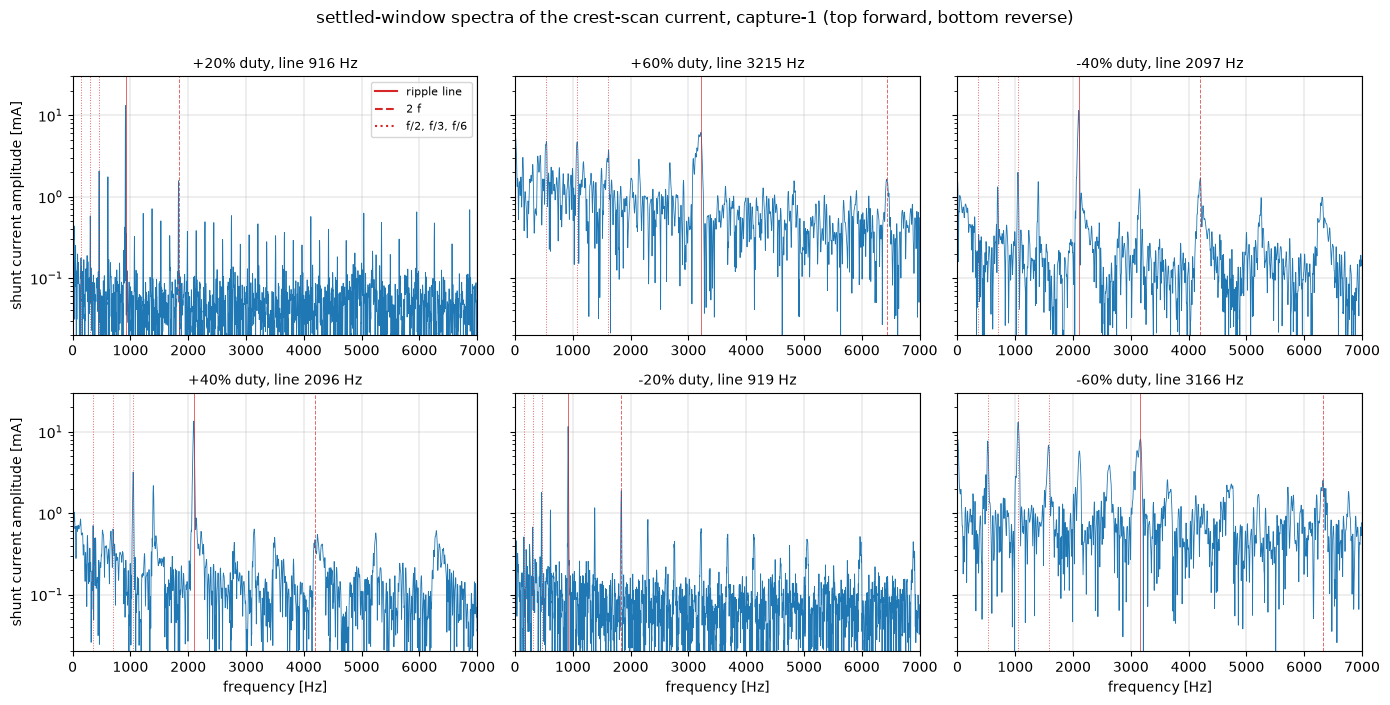

f_line_Hz                     width_Hz                  width_pct               tone_width_Hz                  amp_mA                 line_over_floor                    \
                       mean       min       max     mean     min      max      mean    min    max          mean     min     max    mean     min     max            mean      min      max   
mag_pct direction                                                                                                                                                                           
20      forward     915.165   911.829   916.086    7.353   7.353    7.353     0.803  0.803  0.806         6.863   6.863   6.863  13.237  13.058  13.662         245.301  194.642  289.882   
        reverse     915.894   912.934   918.787    8.529   8.333    9.314     0.931  0.907  1.017         6.863   6.863   6.863  11.637  11.123  12.128         152.422  139.455  167.502   
40      forward    2088.990  2076.800  2095.693   22.856  21.238   24.272     1.094  1.015  1.169        15.170  15.170  15.170  13.509  13.307  13.615         104.272   93.456  119.542   
        reverse    2089.800  2082.215  2097.392   28.317  25.283   31.351     1.355  1.209  1.499        15.170  15.170  15.170  11.256  10.921  11.668          67.510   65.348   70.563   
60      forward    3187.937  3170.645  3214.993   96.737  88.869  104.895     3.034  2.802  3.308        21.853  21.853  21.853   5.644   5.108   6.227           8.207    6.417   10.089   
        reverse    2725.838  1048.598  3166.087   59.149  33.508   99.068     2.305  1.486  3.196        21.853  21.853  21.853  10.236   8.076  15.261          13.239   10.544   18.153   

                  mean_current_A               pot_speed_Vps                 settled_ms                
                            mean    min    max          mean     min     max       mean    min    max  
mag_pct direction                                                                                      
20      forward            0.071  0.070  0.071         3.539   3.532   3.545      255.0  255.0  255.0  
        reverse            0.063  0.063  0.064        -3.630  -3.653  -3.600      255.0  255.0  255.0  
40      forward            0.096  0.093  0.097         8.069   8.024   8.092      123.6  123.6  123.6  
        reverse            0.094  0.093  0.094        -8.272  -8.325  -8.238      123.6  123.6  123.6  
60      forward            0.118  0.117  0.120        12.228  12.157  12.276       85.8   85.8   85.8  
        reverse            0.113  0.110  0.115       -12.421 -12.482 -12.380       85.8   85.8   85.8

In [5]:
F_LO, F_HI = 200.0, 6000.0
SETTLED = 0.6

def line_spectrum(x, nfft_mult=8):
    # Amplitude spectrum in the units of x, coherent gain of the Hann window removed.
    x = detrend(x)
    w = get_window("hann", len(x))
    nfft = nfft_mult * len(x)
    return np.fft.rfftfreq(nfft, DT), np.abs(np.fft.rfft(x * w, nfft)) * 2 / w.sum()

def interp_peak(f, X, lo, hi):
    m = (f >= lo) & (f <= hi)
    Xm, fm = X[m], f[m]
    i = int(np.argmax(Xm))
    d = 0.0
    if 0 < i < len(Xm) - 1:
        a, b, c = np.log(Xm[i - 1]), np.log(Xm[i]), np.log(Xm[i + 1])
        d = 0.5 * (a - c) / (a - 2 * b + c)
    return fm[i] + d * (f[1] - f[0]), Xm[i]

def half_width(f, X, f0):
    m = (f >= 0.7 * f0) & (f <= 1.3 * f0)
    fm, Xm = f[m], X[m]
    i = int(np.argmax(Xm))
    above = Xm >= Xm[i] / 2
    lo = i
    while lo > 0 and above[lo - 1]:
        lo -= 1
    hi = i
    while hi < len(Xm) - 1 and above[hi + 1]:
        hi += 1
    return fm[hi] - fm[lo]

def settled_line(f, X):
    # Largest peak in the band. Where a peak at six, three or two times that
    # frequency is at least half as tall, the lower peak is a sub-line of the
    # family in section 5.3 and the upper one is the ripple line.
    f0, a0 = interp_peak(f, X, F_LO, F_HI)
    for k in (6, 3, 2):
        if k * f0 * 1.05 <= F_HI:
            fk, ak = interp_peak(f, X, k * f0 * 0.95, k * f0 * 1.05)
            if ak >= 0.5 * a0:
                return fk, ak
    return f0, a0

def tone_width(n):
    # Width of a pure tone through the same window and search, the resolution
    # floor of a settled window of n samples.
    x = np.sin(2 * np.pi * 1000.0 * np.arange(n) * DT)
    f, X = line_spectrum(x)
    return half_width(f, X, 1000.0)

def settled(seg):
    n0 = int(len(seg) * (1 - SETTLED))
    return seg.iloc[n0:]

def pot_speed(seg):
    # Least-squares slope of the wiper over the window, in wiper V/s.
    p = seg["pos"].to_numpy() * board.v_adc_per_count
    return np.polyfit(np.arange(len(p)) * DT, p, 1)[0]

def step_line(seg):
    st = settled(seg)
    x = st["current_raw"].to_numpy().astype(float) - st["bias"].iloc[0]
    f, X = line_spectrum(x)
    fr, amp = settled_line(f, X)
    noise = np.median(X[(f >= F_LO) & (f <= F_HI)])
    ratios = {}
    for label, k in [("2f", 2.0), ("f/2", 0.5), ("f/3", 1 / 3), ("f/6", 1 / 6)]:
        _, a = interp_peak(f, X, k * fr * 0.95, k * fr * 1.05)
        ratios[label] = a / amp
    vt = board.div_ratio * (st["vmotor_a"].to_numpy() - st["vmotor_b"].to_numpy()).astype(float)
    ft, Xt = line_spectrum(vt)
    _, amp_t = interp_peak(ft, Xt, fr * 0.97, fr * 1.03)
    xb = st["current_trough"].to_numpy().astype(float) - st["bias"].iloc[0]
    fb, Xb = line_spectrum(xb)
    _, amp_b = interp_peak(fb, Xb, fr * 0.97, fr * 1.03)
    return {
        "duty_pct": seg["duty_pct"].iloc[0],
        "mag_pct": int(seg["mag_pct"].iloc[0]),
        "f_line_Hz": fr,
        "amp_counts": amp,
        "amp_mA": amp * board.a_per_count * 1e3,
        "noise_floor_counts": noise,
        "width_Hz": half_width(f, X, fr),
        "width_pct": half_width(f, X, fr) / fr * 100,
        "tone_width_Hz": tone_width(len(st)),
        "settled_ms": len(st) * DT * 1e3,
        "line_over_floor": amp / noise,
        "mean_current_A": x.mean() * board.a_per_count,
        "pot_speed_Vps": pot_speed(st),
        "terminal_ripple_mV": amp_t * board.v_adc_per_count * 1e3,
        "brake_window_ripple_counts": amp_b,
        **{f"ratio_{k}": v for k, v in ratios.items()},
    }

lines = []
for name, (df, meta) in ripple.items():
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        row = step_line(seg)
        row.update({"recording": name, "seg": seg_id})
        lines.append(row)
lines = pd.DataFrame(lines)
lines["direction"] = np.where(lines["duty_pct"] > 0, "forward", "reverse")
lines["cycles_per_V"] = lines["f_line_Hz"] / lines["pot_speed_Vps"].abs()

name, (df, meta) = next(iter(ripple.items()))
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, (seg_id, seg) in zip(axes.T.flatten(), df[df["seg"] > 0].groupby("seg")):
    st = settled(seg)
    x = st["current_raw"].to_numpy().astype(float) - st["bias"].iloc[0]
    f, X = line_spectrum(x)
    fr = lines[(lines["recording"] == name) & (lines["seg"] == seg_id)]["f_line_Hz"].iloc[0]
    ax.semilogy(f, X * board.a_per_count * 1e3, lw=0.6, color="tab:blue")
    for k, ls in [(1, "-"), (2, "--"), (0.5, ":"), (1 / 3, ":"), (1 / 6, ":")]:
        ax.axvline(k * fr, color="tab:red", lw=0.7, ls=ls, alpha=0.7)
    ax.set_xlim(0, 7000)
    ax.set_ylim(0.02, 30)
    ax.set_title(f"{seg['duty_pct'].iloc[0]:+.0f}% duty, line {fr:.0f} Hz", fontsize=10)
    ax.grid(True, lw=0.3)
for ax in axes[1]:
    ax.set_xlabel("frequency [Hz]")
for ax in axes[:, 0]:
    ax.set_ylabel("shunt current amplitude [mA]")
axes[0, 0].plot([], [], "-", color="tab:red", label="ripple line")
axes[0, 0].plot([], [], "--", color="tab:red", label="2 f")
axes[0, 0].plot([], [], ":", color="tab:red", label="f/2, f/3, f/6")
axes[0, 0].legend(fontsize=8, loc="upper right")
fig.suptitle(f"settled-window spectra of the crest-scan current, {name} (top forward, bottom reverse)", y=1.0)
plt.tight_layout()
plt.show()

cols = ["f_line_Hz", "width_Hz", "width_pct", "tone_width_Hz", "amp_mA", "line_over_floor",
        "mean_current_A", "pot_speed_Vps", "settled_ms"]
lines.groupby(["mag_pct", "direction"])[cols].agg(["mean", "min", "max"]).round(3)


**Rig caveat: the bus line at 1250 Hz.** Section 1 says the telemetry bus
couples into the current amplifier on this board, once every 16 samples,
so it lands in a current spectrum as a fixed line at 1250 Hz with
harmonics at 2500 and 3750 Hz. Those are inside the search band, and this
notebook picks the largest peak in that band, so the artifact has to be
smaller than the ripple line or it will be read as one. The table measures
it. The baseline row is the bridge-off segment, where the ripple does not
exist and the artifact is whatever is there. The step rows are the same
settled windows the table above used. The measurement is a disclosure and
nothing below is filtered.


In [6]:
def line_at(f, X, f0, tol=0.02):
    m = (f >= f0 * (1 - tol)) & (f <= f0 * (1 + tol))
    return float(X[m].max())

rows = []
for name, (df, meta) in ripple.items():
    base = df[df["seg"] == 0]
    f, X = line_spectrum(base["current_raw"].to_numpy().astype(float), nfft_mult=1)
    rows.append({"window": "baseline, bridge off", "recording": name, "ripple_line_counts": np.nan,
                 "median in band [counts]": float(np.median(X[(f >= F_LO) & (f <= F_HI)])),
                 **{f"{int(k * BUS_LINE_HZ)} Hz [counts]": line_at(f, X, k * BUS_LINE_HZ) for k in (1, 2, 3)}})
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        st = settled(seg)
        f, X = line_spectrum(st["current_raw"].to_numpy().astype(float) - st["bias"].iloc[0])
        amp = lines[(lines["recording"] == name) & (lines["seg"] == seg_id)]["amp_counts"].iloc[0]
        rows.append({"window": f"{int(st['mag_pct'].iloc[0])}% step", "recording": name,
                     "ripple_line_counts": amp,
                     "median in band [counts]": float(np.median(X[(f >= F_LO) & (f <= F_HI)])),
                     **{f"{int(k * BUS_LINE_HZ)} Hz [counts]": line_at(f, X, k * BUS_LINE_HZ) for k in (1, 2, 3)}})
bus = pd.DataFrame(rows)
bus["worst bus line [counts]"] = bus[[c for c in bus.columns if c.endswith("Hz [counts]")]].max(axis=1)
bus["ripple over bus"] = bus["ripple_line_counts"] / bus["worst bus line [counts]"]
bus.groupby("window")[["ripple_line_counts", "median in band [counts]", "1250 Hz [counts]",
                       "2500 Hz [counts]", "3750 Hz [counts]", "worst bus line [counts]",
                       "ripple over bus"]].agg(["mean", "max"]).round(3)


ripple_line_counts         median in band [counts]        1250 Hz [counts]        2500 Hz [counts]        3750 Hz [counts]        worst bus line [counts]        ripple over bus  \
                                   mean     max                    mean    max             mean    max             mean    max             mean    max                    mean    max            mean   
window                                                                                                                                                                                                  
20% step                         13.893  15.262                   0.073  0.093            0.275  0.431            0.171  0.248            0.297  0.617                   0.355  0.617          47.493   
40% step                         13.832  15.210                   0.166  0.190            0.315  0.566            0.358  0.533            0.265  0.402                   0.415  0.566          34.767   
60% step                          8.870  17.047                   0.819  0.939            1.382  2.199            1.924  2.829            1.689  2.239                   2.094  2.829           4.182   
baseline, bridge off                NaN     NaN                   0.012  0.012            0.183  0.256            0.138  0.193            0.085  0.141                   0.185  0.256             NaN   

                              
                         max  
window                        
20% step              94.288  
40% step              53.913  
60% step               6.026  
baseline, bridge off     NaN

### 5.2 Ripple frequency against pot speed, and the coupling

**The tracker.** A steady step alone gives one frequency and one speed.
The time-resolved motor angle needs the ripple phase through the whole
step, including the acceleration, where the line sweeps upward from zero.
The tracker below works in two passes. The first pass is a ridge track. A
10 ms Hann window slides over the current in 1 ms hops, starting at the
settled end of the step and walking backward, and in every window the peak
is sought within 15% of the peak of the previous window, a band that
excludes the neighboring members of the sub-line family of section 5.3
(the nearest sits at five sixths of the line) while the line itself moves
by at most 6% per hop at the steepest acceleration seen. The settled-end
seed is the line within 30% of the frequency the pot speed predicts
through a first estimate of the coupling, which keeps the seed off the
sub-lines of section 5.3 - and, as section 5.3 shows, off a sub-line that
outgrows the line itself at 60% duty. The track is accepted from the last
window in which the peak fails to stand at least twice above the median
spectrum or falls below 250 Hz, and the first 5 ms of the accepted track
are dropped. A step whose track collapses entirely is not accepted at all.
The second pass is a demodulation. The current is mixed down with the
phase of the ridge, low-passed at a quarter of the lowest ridge frequency
(a zero-phase filter run over a 50 ms extension at both ends), and the
unwrapped residual phase is added back. The result is
the ripple phase in cycles at every sample, exact to a fraction of a cycle
wherever the line is present, with the ridge's interpolation error removed.

For every steady step the figure plots the settled line frequency against
the settled pot speed, and for every accepted grid step from 30% to 55%
the line frequency and pot speed over the accepted window. The coupling
$C$ of a step is the demodulated cycle count divided by the pot travel
over the accepted window, which averages the pot's periodic error over
the whole travel and is the estimate carried forward. The table gives it
by duty and direction with the spread across captures.


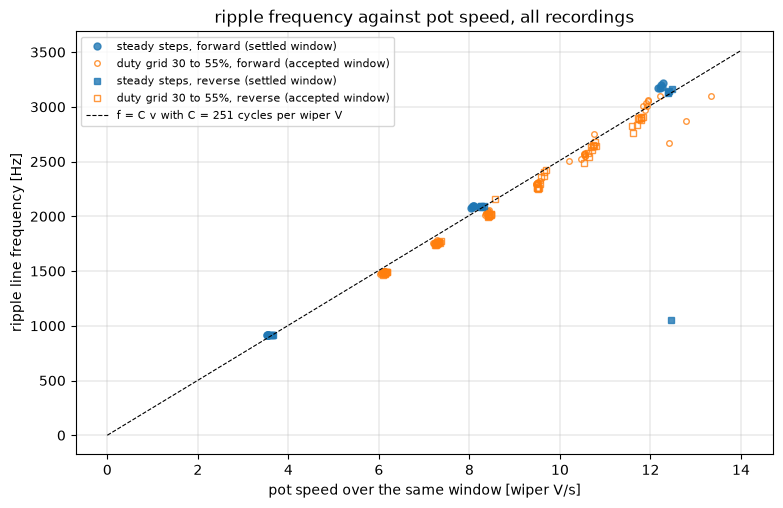

mean    std     min     max  count  travel_V
campaign     mag_pct direction                                                
duty grid    30      forward    252.22   0.57  251.39  253.20     10      2.16
                     reverse    252.05   0.81  251.13  253.15     10     -2.17
             35      forward    252.08   1.20  249.88  253.56     10      2.19
                     reverse    251.91   0.65  251.04  252.78     10     -2.18
             40      forward    251.90   0.94  249.66  252.89     10      2.20
                     reverse    251.66   0.62  250.88  253.25     10     -2.17
             45      forward    249.66   2.13  243.85  251.18     10      2.02
                     reverse    251.12   0.72  249.78  251.72     10     -2.14
             50      forward    251.03   1.26  249.27  252.88      8      2.14
                     reverse    250.81   1.26  249.43  252.87     10     -2.12
             55      forward    243.18  10.51  221.49  251.79     10      1.29
                     reverse    250.29   1.15  248.87  252.31     10     -2.10
steady steps 20      forward    252.58   0.99  251.22  253.77      5      1.43
                     reverse    247.65   1.23  246.61  249.74      5     -1.45
             40      forward    253.03   1.04  251.65  254.06      5      1.48
                     reverse    248.58   1.22  246.63  249.45      5     -1.50
             60      forward    255.97   1.36  254.46  257.11      3      0.69
                     reverse    248.69   0.48  248.04  249.31      5     -1.37

In [7]:
def ridge_track(x, seed, win=200, hop=20, tol=0.15, fmin=150.0, fmax=F_HI, nfft=8192):
    # Sliding-window peak track, walking backward from the end, seeded with the settled line.
    w = get_window("hann", win)
    f = np.fft.rfftfreq(nfft, DT)
    band = (f >= fmin) & (f <= fmax)
    out = []
    fprev = seed
    for c in np.arange(win // 2, len(x) - win // 2, hop)[::-1]:
        X = np.abs(np.fft.rfft(detrend(x[c - win // 2:c + win // 2]) * w, nfft)) * 2 / w.sum()
        fpk, amp = interp_peak(f, X, max(fmin, fprev * (1 - tol)), min(fmax, fprev * (1 + tol)))
        out.append((c, fpk, amp, np.median(X[band])))
        fprev = fpk
    return pd.DataFrame(out[::-1], columns=["n", "f", "amp", "noise"])

def demod_cycles(x, n_ref, f_ref, lp_frac=0.25):
    # Ripple phase in cycles at every sample: mix down with the ridge phase,
    # low-pass, unwrap the residual, add the ridge phase back.
    n = np.arange(len(x))
    fref = np.interp(n, n_ref, f_ref)
    phref = 2 * np.pi * np.cumsum(fref) * DT
    z = detrend(x) * np.exp(-1j * phref)
    sos = butter(3, max(30.0, lp_frac * fref.min()), "lowpass", fs=board.tick_hz, output="sos")
    zb = sosfiltfilt(sos, z, padlen=min(1000, len(z) - 1))
    return (phref + np.unwrap(np.angle(zb))) / (2 * np.pi)

def motor_angle(seg, c_prior, snr_min=2.0, f_floor=250.0, prior_tol=0.3):
    # Cycles at every sample of a drive step and the first accepted sample.
    x = seg["current_raw"].to_numpy().astype(float) - seg["bias"].iloc[0]
    st = settled(seg)
    v = abs(pot_speed(st))
    f, X = line_spectrum(x[len(seg) - len(st):])
    seed, _ = interp_peak(f, X, max(F_LO, c_prior * v * (1 - prior_tol)), min(F_HI, c_prior * v * (1 + prior_tol)))
    r = ridge_track(x, seed)
    ok = ((r["amp"] / r["noise"] >= snr_min) & (r["f"] >= f_floor)).to_numpy()
    bad = np.where(~ok)[0]
    r = r.iloc[bad.max() + 1:] if len(bad) else r
    if len(r) < 2:                      # nothing in the step tracked
        return None, None, None
    cyc = demod_cycles(x, r["n"].to_numpy(), r["f"].to_numpy())
    return cyc, int(r["n"].iloc[0]) + 100, r

# First estimate of the coupling from the settled 20% and 40% lines, which
# are unambiguous (section 5.3), used only to seed the tracker.
C_PRIOR = lines[lines["mag_pct"] <= 40]["cycles_per_V"].median()
MIN_TRAVEL_V = 0.15

def track_step(seg, campaign, name):
    d = np.sign(seg["duty_pct"].iloc[0])
    cyc, n0, r = motor_angle(seg, C_PRIOR)
    if cyc is None or n0 >= len(seg) - 200:
        return None, None
    p = seg["pos"].to_numpy()[n0:] * board.v_adc_per_count
    th = (cyc[n0:] - cyc[n0]) * d
    if p.max() - p.min() < MIN_TRAVEL_V:
        return None, None
    k = np.polyfit(th, p, 1)
    win = seg.iloc[n0:]
    row = {
        "campaign": campaign, "recording": name, "seg": int(seg["seg"].iloc[0]),
        "mag_pct": int(seg["mag_pct"].iloc[0]),
        "direction": "forward" if d > 0 else "reverse",
        "cycles": th[-1], "travel_V": p[-1] - p[0],
        "cycles_per_V": th[-1] / (p[-1] - p[0]),
        "mV_per_cycle_fit": k[0] * 1e3,
        "residual_rms_mV": (p - np.polyval(k, th)).std() * 1e3,
        "accepted_from_ms": n0 * DT * 1e3,
        "window_line_Hz": r["f"].mean(),
        "window_pot_speed_Vps": abs(pot_speed(win)),
        "p_lo_V": p.min(), "p_hi_V": p.max(),
    }
    trace = pd.DataFrame({"campaign": campaign, "recording": name, "seg": row["seg"],
                          "mag_pct": row["mag_pct"], "direction": row["direction"],
                          "p": p, "theta": th, "res": p - np.polyval(k, th)})
    return row, trace

steps, traces = [], []
for name, (df, meta) in ripple.items():
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        row, trace = track_step(seg, "steady steps", name)
        if row:
            steps.append(row)
            traces.append(trace)
for name, (df, meta) in grid.items():
    for seg_id, seg in df[(df["mag_pct"] >= 30) & (df["mag_pct"] <= 55)].groupby("seg"):
        row, trace = track_step(seg, "duty grid", name)
        if row:
            steps.append(row)
            traces.append(trace)
steps = pd.DataFrame(steps)
traces = pd.concat(traces, ignore_index=True)

C_MEAN = steps["cycles"].abs().sum() / steps["travel_V"].abs().sum()     # travel-weighted, both campaigns
fig, ax = plt.subplots(figsize=(9, 5.5))
for dname, mk in [("forward", "o"), ("reverse", "s")]:
    g = lines[lines["direction"] == dname]
    ax.plot(g["pot_speed_Vps"].abs(), g["f_line_Hz"], mk, ms=5, color="tab:blue", alpha=0.8,
            label=f"steady steps, {dname} (settled window)")
    g = steps[(steps["campaign"] == "duty grid") & (steps["direction"] == dname)]
    ax.plot(g["window_pot_speed_Vps"], g["window_line_Hz"], mk, ms=4, mfc="none", color="tab:orange",
            alpha=0.8, label=f"duty grid 30 to 55%, {dname} (accepted window)")
vv = np.linspace(0, 1.05 * max(lines["pot_speed_Vps"].abs().max(), steps["window_pot_speed_Vps"].max()), 50)
ax.plot(vv, C_MEAN * vv, "k--", lw=0.8, label=f"f = C v with C = {C_MEAN:.0f} cycles per wiper V")
ax.set_xlabel("pot speed over the same window [wiper V/s]")
ax.set_ylabel("ripple line frequency [Hz]")
ax.set_title("ripple frequency against pot speed, all recordings")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()

coupling = (steps.groupby(["campaign", "mag_pct", "direction"])["cycles_per_V"]
            .agg(["mean", "std", "min", "max", "count"]))
coupling["travel_V"] = steps.groupby(["campaign", "mag_pct", "direction"])["travel_V"].mean()
coupling.round(2)


In [8]:
def pooled_row(label, g):
    r = g["cycles_per_V"].agg(["mean", "std", "min", "max", "count"])
    r["travel_weighted"] = g["cycles"].abs().sum() / g["travel_V"].abs().sum()
    return {"set": label, **r}

pooled = pd.DataFrame([
    pooled_row("steady steps, all", steps[steps["campaign"] == "steady steps"]),
    pooled_row("steady steps, 40% and 60%", steps[(steps["campaign"] == "steady steps") & (steps["mag_pct"] >= 40)]),
    pooled_row("duty grid 30 to 45%", steps[(steps["campaign"] == "duty grid") & (steps["mag_pct"] <= 45)]),
    pooled_row("duty grid 50 to 55%", steps[(steps["campaign"] == "duty grid") & (steps["mag_pct"] > 45)]),
    pooled_row("duty grid 30 to 55%, all", steps[steps["campaign"] == "duty grid"]),
    pooled_row("both campaigns", steps),
    {"set": "settled-window ratio f / v, steady steps", **lines["cycles_per_V"].agg(["mean", "std", "min", "max", "count"]),
     "travel_weighted": np.nan},
]).set_index("set")
pooled["spread_pct"] = (pooled["max"] - pooled["min"]) / pooled["mean"] * 100
pooled["mV_per_cycle"] = 1e3 / pooled["mean"]
pooled["motor_rev_per_wiper_V"] = pooled["mean"] / PULSES.value
pooled.round(2)


,mean,std,min,max,count,travel_weighted,spread_pct,mV_per_cycle,motor_rev_per_wiper_V
set,,,,,,,,,
"steady steps, all",250.74,2.99,246.61,257.11,28.0,250.43,4.19,3.99,41.79
"steady steps, 40% and 60%",251.08,3.12,246.63,257.11,18.0,250.63,4.18,3.98,41.85
duty grid 30 to 45%,251.57,1.29,243.85,253.56,80.0,251.65,3.86,3.97,41.93
duty grid 50 to 55%,248.71,6.26,221.49,252.88,38.0,249.96,12.62,4.02,41.45
"duty grid 30 to 55%, all",250.65,3.92,221.49,253.56,118.0,251.15,12.80,3.99,41.78
both campaigns,250.67,3.75,221.49,257.11,146.0,251.05,14.21,3.99,41.78
"settled-window ratio f / v, steady steps",250.44,31.58,84.24,261.93,30.0,NaN,70.95,3.99,41.74


### 5.3 Amplitude, harmonics and the line family


In [9]:
cols = ["mean_current_A", "amp_mA", "ratio_2f", "ratio_f/2", "ratio_f/3", "ratio_f/6",
        "terminal_ripple_mV", "brake_window_ripple_counts"]
tab = lines.groupby("mag_pct")[cols].agg(["mean", "min", "max"]).round(3)
tab[("amp_over_mean_current_pct", "mean")] = (lines["amp_mA"] / (lines["mean_current_A"] * 1e3)).groupby(lines["mag_pct"]).mean().round(3) * 100
tab[("terminal_ripple_per_current_ohm", "mean")] = (lines["terminal_ripple_mV"] / lines["amp_mA"]).groupby(lines["mag_pct"]).mean().round(3)
tab


mean_current_A                amp_mA                 ratio_2f               ratio_f/2               ratio_f/3               ratio_f/6               terminal_ripple_mV                 \
                  mean    min    max    mean     min     max     mean    min    max      mean    min    max      mean    min    max      mean    min    max               mean    min     max   
mag_pct                                                                                                                                                                                         
20               0.067  0.063  0.071  12.437  11.123  13.662    0.151  0.119  0.179     0.164  0.147  0.185     0.048  0.030  0.065     0.025  0.009  0.044              9.683  8.921  10.311   
40               0.095  0.093  0.097  12.383  10.921  13.615    0.089  0.035  0.148     0.213  0.174  0.247     0.087  0.020  0.148     0.080  0.029  0.149              7.715  7.506   8.014   
60               0.115  0.110  0.120   7.940   5.108  15.261    0.348  0.266  0.491     0.860  0.469  1.041     1.159  0.094  1.718     0.891  0.095  1.495              4.428  2.334  11.319   

        brake_window_ripple_counts               amp_over_mean_current_pct terminal_ripple_per_current_ohm  
                              mean    min    max                      mean                            mean  
mag_pct                                                                                                     
20                           0.071  0.048  0.089                      18.5                           0.780  
40                           0.091  0.065  0.154                      13.1                           0.629  
60                           0.143  0.063  0.321                       6.9                           0.528

### 5.4 What the coupling is a measurement of

The coupling is often read as a gear ratio in disguise. It is not, and this
is the section that says so.

The gear ratio is not in dispute. It is 234.73:1, the product of the counted
teeth (47x38x32x23 over 10x10x8x7) in the mechanical package, and the six
commutation pulses per motor revolution are a parts count too, three
commutator segments crossed by two brushes, confirmed by teardown and
agreeing with an optical tachometer to 0.7%. Both are exact inputs, not
fits, and both are printed by the registry cell in section 2. So a ripple
cycle is $1/6$ of a motor revolution and an output revolution is
$6 \times 234.73 = 1408.4$ ripple cycles, full stop.

What $C$ measures, then, is the POT. It converts a counted mechanical fact
into wiper volts, so a coupling of $C$ cycles per wiper volt says the wiper
covers $1408.4 / C$ volts per output revolution, and that is a pot scale in
counts per degree. Running the arithmetic the other way, taking the pot
scale as known and calling the result a gear ratio, just folds the pot's
error into a number that was counted with a magnifier: the last column of
the table does that on purpose and reads 242:1, 3.2% off, and with the
coupling the servo entry carries it would read 256:1, 9% off. The pot is
the unknown here, not the gears.

Which makes the spread of $C$ interesting rather than annoying. The table
sets the coupling from each campaign beside the pot scale it implies, the
scale the servo entry declares from eyeballed horn angles, and the scale
that entry carries as measured. The last rows run the same tracker over the
USB captures as a check that the coupling does not follow the supply.


In [10]:
CYCLES_PER_OUTPUT_REV = PULSES.value * RATIO.value

def pot_scale(c):
    # C cycles per wiper V, with the ratio and the pulse count both counted,
    # fixes the wiper scale: counts per degree of output shaft.
    v_per_rev = CYCLES_PER_OUTPUT_REV / c
    return v_per_rev / board.v_adc_per_count / 360.0

def c_row(label, g):
    c_tw = g["cycles"].abs().sum() / g["travel_V"].abs().sum()
    return {"set": label, "steps": len(g),
            "C mean [cycles per wiper V]": g["cycles_per_V"].mean(),
            "C sd": g["cycles_per_V"].std(),
            "C cv [%]": g["cycles_per_V"].std() / g["cycles_per_V"].mean() * 100,
            "C travel weighted": c_tw,
            "covered from [wiper V]": g["p_lo_V"].min(), "to [wiper V]": g["p_hi_V"].max(),
            "pot scale [counts per deg]": pot_scale(c_tw),
            "gear ratio if the declared pot scale were right":
                c_tw * servo.pos_per_deg * 360.0 * board.v_adc_per_count / PULSES.value}

grid_steps_2s = steps[steps["campaign"] == "duty grid"]
rows = [
    c_row("2S steady steps, 40% and 60%", steps[(steps["campaign"] == "steady steps") & (steps["mag_pct"] >= 40)]),
    c_row("2S duty grid, 30 to 45%", grid_steps_2s[grid_steps_2s["mag_pct"] <= 45]),
    c_row("2S duty grid, 50 to 55%", grid_steps_2s[grid_steps_2s["mag_pct"] > 45]),
    c_row("2S both campaigns", steps),
]

# The same tracker over the USB steady steps, as a supply check.
usb_ripple = load_campaign(ds_usb, "ripple")
usb_rows = []
for name, (df, meta) in usb_ripple.items():
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        row, _ = track_step(seg, "steady steps", name)
        if row:
            usb_rows.append(row)
usb_steps = pd.DataFrame(usb_rows)
rows.append(c_row("USB steady steps, all", usb_steps))
rows.append(c_row("USB steady steps, 40% and 60%", usb_steps[usb_steps["mag_pct"] >= 40]))

scale = pd.DataFrame(rows).set_index("set")
scale["pot scale vs declared [%]"] = (scale["pot scale [counts per deg]"] / servo.pos_per_deg - 1) * 100
scale["pot scale vs measured [%]"] = (scale["pot scale [counts per deg]"]
                                      / servo.measured["pot_scale_measured"].value - 1) * 100
display(scale.round(3))
pd.DataFrame([
    {"quantity": "gear ratio, counted teeth", "value": RATIO.value, "unit": ":1", "source": RATIO.source},
    {"quantity": "ripple cycles per motor rev, counted", "value": PULSES.value, "unit": "cycles", "source": PULSES.source},
    {"quantity": "ripple cycles per output rev", "value": CYCLES_PER_OUTPUT_REV, "unit": "cycles", "source": "the two above"},
    {"quantity": "pot scale, declared", "value": servo.pos_per_deg, "unit": "counts per deg", "source": "eyeballed horn angles"},
    {"quantity": "pot scale, servo entry measured", "value": servo.measured["pot_scale_measured"].value,
     "unit": "counts per deg", "source": servo.measured["pot_scale_measured"].source},
]).set_index("quantity").round(3)


,steps,C mean [cycles per wiper V],C sd,C cv [%],C travel weighted,covered from [wiper V],to [wiper V],pot scale [counts per deg],gear ratio if the declared pot scale were right,pot scale vs declared [%],pot scale vs measured [%]
set,,,,,,,,,,,
"2S steady steps, 40% and 60%",18,251.081,3.118,1.242,250.627,0.323,2.957,19.375,241.821,-2.932,5.931
"2S duty grid, 30 to 45%",80,251.575,1.295,0.515,251.653,0.317,2.953,19.296,242.810,-3.328,5.499
"2S duty grid, 50 to 55%",38,248.709,6.259,2.517,249.960,0.328,2.938,19.426,241.178,-2.673,6.213
2S both campaigns,146,250.668,3.747,1.495,251.054,0.306,2.957,19.342,242.233,-3.097,5.750
"USB steady steps, all",30,252.494,2.741,1.085,252.545,0.358,2.902,19.228,243.671,-3.669,5.126
"USB steady steps, 40% and 60%",20,252.049,2.826,1.121,252.058,0.358,2.902,19.265,243.202,-3.483,5.329


,value,unit,source
quantity,,,
"gear ratio, counted teeth",234.73,:1,mechanical/sg90/measurements.py
"ripple cycles per motor rev, counted",6.00,cycles,bringup isns-diff runs 25-27
ripple cycles per output rev,1408.38,cycles,the two above
"pot scale, declared",19.96,counts per deg,eyeballed horn angles
"pot scale, servo entry measured",18.29,counts per deg,"ripple tach vs counted gear ratio, 2S grid 30-..."


Findings for section 5:

- **The line.** Every settled step shows one dominant line, at 915 Hz for
  20% duty in both directions, 2089 Hz at 40%, and 3188 Hz at 60% forward.
  Those are 1.6 times the USB session's, which is the supply. The line
  stands 152 to 245 times above the median spectrum at 20%, 68 to 104 times
  at 40%, and 8 to 13 times at 60%, where the noise floor rises with the
  current and the line itself weakens.
- **At 60% duty the line loses its own family.** The sub-lines below the
  line grow with duty until, at 60%, the peak at $f_r/3$ is on average
  1.16 times the line and the one at $f_r/2$ is 0.86 times it, where at
  20% they are 0.05 and 0.16. The settled-line rule, which promotes the
  largest peak to its multiple when the multiple is at least half as tall,
  does not always rescue that: some 60% reverse steps report a line near
  1050 Hz, one third of the true 3170 Hz, which is why the 60% reverse row
  reads a mean of 2726 Hz with a minimum of 1049. Only the settled-window
  table and the $f/v$ ratio row of the pooled table carry that error. The
  tracker seeds from the pot speed rather than from the largest peak, so
  the coupling below is unaffected, and it is the reason the seed is
  built that way.
- **The bus line.** The board's telemetry coupling shows up where section
  1 said it would. The bridge-off baseline carries a line at 1250 Hz of
  0.18 counts against a median spectrum of 0.01, so it is the largest thing
  in an idle current spectrum. Inside a 20% or 40% step the three bus lines
  run 0.36 to 0.42 counts on average and the ripple line is 35 to 47 times
  taller. At 60% the bus lines reach 2.1 counts on average and 2.8 at
  worst, and the margin falls to 4.2 times on average, 3.0 times in the
  worst single step. The artifact is real, it is measurable, it grows with
  the current, and it still does not reach the tachometer. Nothing is
  filtered.
- **Width.** The full width at half amplitude is 7.4 to 8.5 Hz at 20%
  (0.80 to 0.93% of the line), 23 to 28 Hz at 40% (1.0 to 1.4%), and 97 Hz
  at 60% forward (3.0%), against a pure-tone floor of 6.9, 15.2 and 21.9 Hz
  for the settled windows of those three duties. So at 20% the line is only
  about 1.1 times wider than the resolution floor and at 60% it is 4.4
  times wider. *Hypothesis (not tested here): the excess width is the chirp
  of a speed still rising in the settled window, plus the once-per-revolution
  modulation whose sidebands are the family above, which would explain why
  the excess grows with duty in step with that family.*
- **Frequency against speed.** The line frequency is proportional to the
  pot speed. Over the thirty settled windows the ratio averages 250
  cycles per wiper volt, but with a 71% spread, which is entirely the
  handful of 60% steps that picked a sub-line. The demodulated coupling
  below does not use this ratio and does not carry that error.
- **The coupling, and it is the same on both supplies.** Counted as
  demodulated cycles per volt of travel, the 40% and 60% steady steps give
  250.6 cycles per wiper volt, the duty grid at 30 to 45% gives 251.7, and
  both campaigns together give 251.1 travel-weighted, 3.98 mV of wiper per
  cycle. The USB captures put the steady steps at 252.5, 0.6% away. The
  per-step spread is 0.5% within the grid's 30 to 45% band and 1.5% over
  everything. This is the number this notebook carries forward.
- **The spread that is left is position, not noise.** The grid's 50 to 55%
  band reads 250.0 with a 2.5% spread against 251.7 and 0.5% at 30 to 45%,
  and the outliers are steps whose accepted window covers less travel: the
  55% forward group averages 243 with one step down at 221, and its
  accepted windows average 1.29 V of travel where every other group covers
  2.1 to 2.2 V. A step that covers less travel
  samples less of the pot, and section 6 shows the pot's local gain is not
  constant over that travel, so a short window returns the local coupling
  of wherever it sat. Forward steps read 252.6 to 256.0 and reverse steps
  247.7 to 248.7, a 2% asymmetry that survives averaging over the same
  positions, which is what the play of section 7 does to a cycle count that
  starts at a direction change.
- **Amplitude.** The line amplitude is 12.4 mA at 20% and at 40% and
  7.9 mA at 60%, which is 18.5%, 13.1% and 6.9% of the mean drive current.
  The same ripple appears on the terminal difference at 9.7, 7.7 and
  4.4 mV, which is 0.78, 0.63 and 0.53 Ohm per ampere of ripple across the
  three duties. *Hypothesis (not tested here): the terminal ripple is the
  current ripple across the on-resistance of the bridge and the shunt,
  about 0.3 Ohm on the low side alone by notebook 01, so at 20% duty
  something else in the terminal path carries the other half, and whatever
  it is falls away with duty.* The brake-window shunt sample carries 0.07
  to 0.14 counts at the line against 10 to 15 counts on the crest-scan
  sample, two orders of magnitude down. The ripple is a drive-window
  feature and the trough scan cannot serve as a tachometer.
- **Harmonics and sub-lines.** The second harmonic is 0.09 to 0.35 of the
  line. Below the line there is a family at one half, one third and one
  sixth of its frequency, which at 20% and 40% duty runs 0.16 to 0.21,
  0.05 to 0.09 and 0.03 to 0.08 of the line, and at 60% duty runs 0.86,
  1.16 and 0.89. With six pulses per revolution these are the first, second
  and third harmonics of a once-per-revolution modulation, and the growth
  with speed is steep. *Hypothesis (not tested here): the modulation is a
  brush or commutator asymmetry whose effect grows with speed, brush bounce
  being the obvious candidate, which makes the six commutation steps of a
  revolution progressively more unequal as the motor runs faster. It is
  testable on the bench with the optical tachometer that already confirmed
  the six.*


## 6. Pot linearity

### 6.1 Motor-side angle against the pot inside a step

The demodulated ripple phase of section 5.2 is a motor-side angle in
cycles at every sample. Within one step the pot position is plotted
against it and a line is fitted. The residual of the pot from that line is
the pot's departure from proportionality to the motor angle, in wiper
volts, as a function of position. The left panel shows one 60% step, with
the motor angle and the pot against time. The right panel overlays the
residual of every accepted 40% step of the steady-step campaign against
absolute position, forward and reverse. Every trace has its own fitted
line, so the offsets between traces carry no information and the shapes
do.


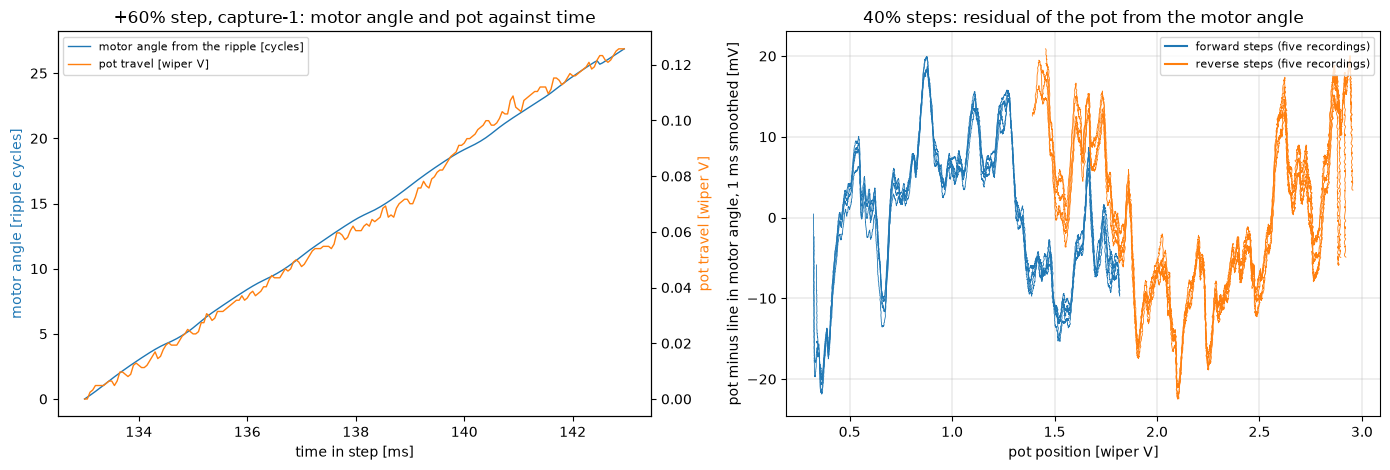

cycles_per_V                 residual_rms_mV              travel_V             accepted_from_ms             
                          mean     min     max            mean   min    max     mean   min   max             mean   min    max
mag_pct direction                                                                                                             
20      forward         252.58  251.22  253.77            8.83  7.88   9.33     1.43  1.42  1.44            16.80  10.0   20.0
        reverse         247.65  246.61  249.74            9.87  9.59  10.11    -1.45 -1.46 -1.44            18.60  17.0   20.0
40      forward         253.03  251.65  254.06            8.95  8.39   9.31     1.48  1.47  1.48            12.00  10.0   16.0
        reverse         248.58  246.63  249.45            9.84  9.43  10.17    -1.50 -1.50 -1.49            12.20  10.0   17.0
60      forward         255.97  254.46  257.11            5.24  2.62   6.69     0.69  0.18  0.96            86.67  65.0  128.0
        reverse         248.69  248.04  249.31            8.83  8.55   9.10    -1.37 -1.38 -1.34            29.60  27.0   33.0

In [11]:
name, (df, meta) = next(iter(ripple.items()))
seg = df[df["seg"] == 3]
cyc, n0, r = motor_angle(seg, C_PRIOR)
t = np.arange(len(seg)) * DT * 1e3
p = seg["pos"].to_numpy() * board.v_adc_per_count

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
ax = axes[0]
ax.plot(t[n0:], cyc[n0:] - cyc[n0], color="tab:blue", lw=1, label="motor angle from the ripple [cycles]")
ax.set_xlabel("time in step [ms]")
ax.set_ylabel("motor angle [ripple cycles]", color="tab:blue")
ax2 = ax.twinx()
ax2.plot(t[n0:], p[n0:] - p[n0], color="tab:orange", lw=1, label="pot travel [wiper V]")
ax2.set_ylabel("pot travel [wiper V]", color="tab:orange")
ax.set_title(f"+60% step, {name}: motor angle and pot against time")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)
ax = axes[1]
for (rec, sid), g in traces[(traces["campaign"] == "steady steps") & (traces["mag_pct"] == 40)].groupby(["recording", "seg"]):
    rs = np.convolve(g["res"].to_numpy(), np.ones(20) / 20, mode="same")
    ax.plot(g["p"].to_numpy()[10:-10], rs[10:-10] * 1e3, lw=0.6,
            color="tab:blue" if g["direction"].iloc[0] == "forward" else "tab:orange")
ax.plot([], [], color="tab:blue", label="forward steps (five recordings)")
ax.plot([], [], color="tab:orange", label="reverse steps (five recordings)")
ax.set_xlabel("pot position [wiper V]")
ax.set_ylabel("pot minus line in motor angle, 1 ms smoothed [mV]")
ax.set_title("40% steps: residual of the pot from the motor angle")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()

cols = ["cycles_per_V", "residual_rms_mV", "travel_V", "accepted_from_ms"]
steps[steps["campaign"] == "steady steps"].groupby(["mag_pct", "direction"])[cols].agg(["mean", "min", "max"]).round(2)


### 6.2 Wiper volts per ripple cycle against position

The local gain of the pot is the slope of position against motor angle
within a bin of position. It is fitted in consecutive windows of five
cycles (about 20 mV) on every accepted trace of both campaigns, each
window placed at its mean position, and pooled in 20 mV bins of position,
which needs no alignment between traces since a slope has no offset.
Windows are cut on the motor angle, the independent variable of the fit,
so the pooled slope is unbiased. The figure shows the pooled
local gain against position with the spread across traces, and the table
reduces it to 0.25 V bands. Two more figures of merit follow. The
reproducibility of the pattern is the rms difference between the residual
traces of different recordings at the same positions, taken within each
group of steps that covers the same range. The lower panel integrates the
pooled gain into the pot's departure from proportionality over the whole
covered range, one curve free of per-trace offsets, and the quasi-period
of the pattern is the spacing of its successive maxima. The summary ends
with the extreme local gains and their positions in the min column, then
the positions of the two sticky codes of section 4.1 for comparison.


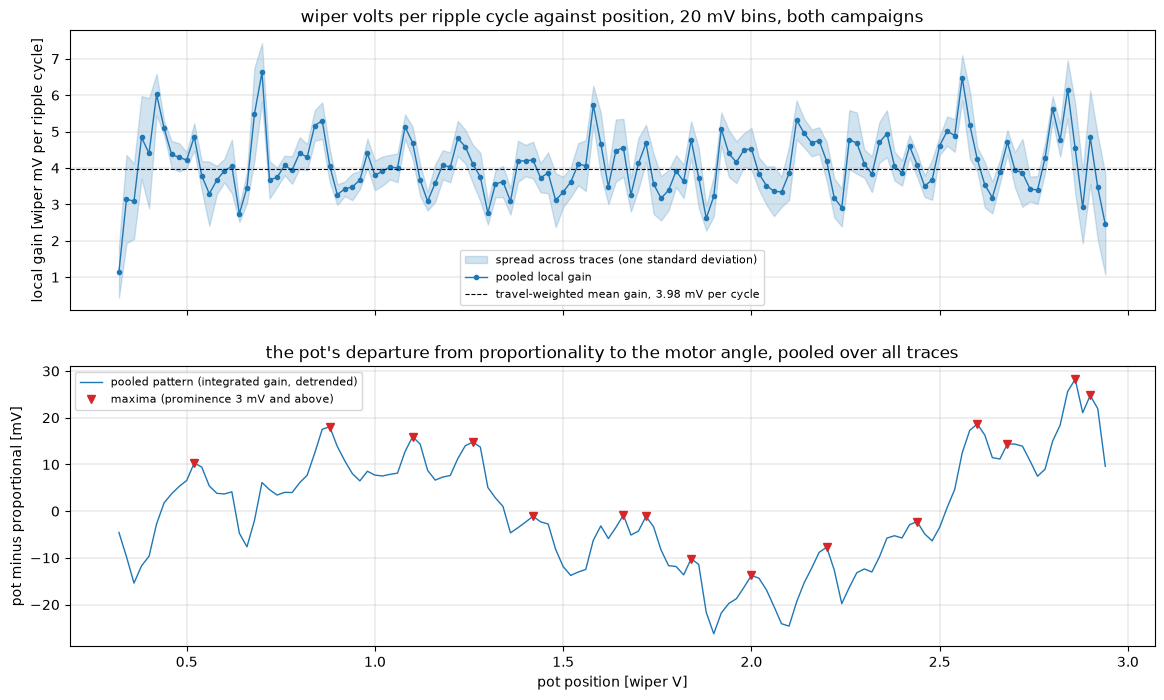

,mV_per_cycle,cycles_per_V,gain_min,gain_min_at_V,gain_max,gain_max_at_V,within_band_swing_pct,traces_per_bin
band_V,,,,,,,,
0.25,4.28,233.68,1.14,0.32,6.02,0.42,120.60,40.22
0.50,3.97,252.11,2.75,0.64,6.62,0.70,94.21,62.92
0.75,4.04,247.77,3.27,0.90,5.30,0.86,49.19,119.00
1.00,4.04,247.33,3.09,1.14,5.13,1.08,49.68,123.46
1.25,3.62,275.98,2.77,1.30,4.22,1.42,39.41,141.42
1.50,4.04,247.76,3.26,1.68,5.73,1.58,59.72,139.77
1.75,3.76,266.16,2.62,1.88,5.07,1.92,63.28,140.58
2.00,3.90,256.16,2.91,2.24,5.32,2.12,59.67,133.85
2.25,4.19,238.77,3.50,2.46,4.94,2.36,34.09,126.42


In [12]:
BIN_V = 0.02
WIN_CYCLES = 5

def local_gains(trace):
    # Slope of position against motor angle in consecutive windows of five
    # cycles (about 20 mV), each placed at its mean position. Windows are cut
    # on the motor angle, the independent variable, so the slope is unbiased.
    p, th = trace["p"].to_numpy(), trace["theta"].to_numpy()
    out = []
    for a in np.arange(th.min(), th.max() - WIN_CYCLES, WIN_CYCLES):
        m = (th >= a) & (th < a + WIN_CYCLES)
        if m.sum() >= 20:
            out.append({"bin_V": np.round(p[m].mean() / BIN_V) * BIN_V,
                        "mV_per_cycle": np.polyfit(th[m], p[m], 1)[0] * 1e3})
    return pd.DataFrame(out)

gains = []
for (camp, rec, sid), g in traces.groupby(["campaign", "recording", "seg"]):
    lg = local_gains(g)
    lg["campaign"], lg["recording"], lg["seg"], lg["direction"] = camp, rec, sid, g["direction"].iloc[0]
    gains.append(lg)
gains = pd.concat(gains, ignore_index=True)
gmap = gains.groupby("bin_V")["mV_per_cycle"].agg(["mean", "std", "count"]).reset_index()
gmap = gmap[gmap["count"] >= 8].sort_values("bin_V").reset_index(drop=True)
G_MEAN = 1e3 / C_MEAN

# Pooled pattern: the residual of the pot from proportionality, integrated
# from the pooled gain over a contiguous 20 mV grid (missing bins take the
# mean gain), then detrended.
gridp = np.arange(gmap["bin_V"].min(), gmap["bin_V"].max() + BIN_V / 2, BIN_V)
gain_on_grid = np.interp(gridp, gmap["bin_V"], gmap["mean"])
gain_on_grid[np.abs(gridp[:, None] - gmap["bin_V"].to_numpy()[None, :]).min(axis=1) > BIN_V / 2] = G_MEAN
pattern = np.cumsum((1 - G_MEAN / gain_on_grid) * BIN_V)
pattern -= np.polyval(np.polyfit(gridp, pattern, 1), gridp)
pk_idx, _ = find_peaks(pattern, prominence=0.003)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax = axes[0]
ax.fill_between(gmap["bin_V"], gmap["mean"] - gmap["std"], gmap["mean"] + gmap["std"], color="tab:blue", alpha=0.2,
                label="spread across traces (one standard deviation)")
ax.plot(gmap["bin_V"], gmap["mean"], "-o", ms=3, lw=1, color="tab:blue", label="pooled local gain")
ax.axhline(G_MEAN, color="k", lw=0.8, ls="--", label=f"travel-weighted mean gain, {G_MEAN:.2f} mV per cycle")
ax.set_ylabel("local gain [wiper mV per ripple cycle]")
ax.set_title("wiper volts per ripple cycle against position, 20 mV bins, both campaigns")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
ax = axes[1]
ax.plot(gridp, pattern * 1e3, "-", lw=1, color="tab:blue", label="pooled pattern (integrated gain, detrended)")
ax.plot(gridp[pk_idx], pattern[pk_idx] * 1e3, "v", color="tab:red", ms=6, label="maxima (prominence 3 mV and above)")
ax.set_xlabel("pot position [wiper V]")
ax.set_ylabel("pot minus proportional [mV]")
ax.set_title("the pot's departure from proportionality to the motor angle, pooled over all traces")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()

gmap["band_V"] = (gmap["bin_V"] // 0.25) * 0.25
bands = gmap.groupby("band_V").apply(lambda g: pd.Series({
    "mV_per_cycle": np.average(g["mean"], weights=g["count"]),
    "cycles_per_V": 1e3 / np.average(g["mean"], weights=g["count"]),
    "gain_min": g["mean"].min(), "gain_min_at_V": g.loc[g["mean"].idxmin(), "bin_V"],
    "gain_max": g["mean"].max(), "gain_max_at_V": g.loc[g["mean"].idxmax(), "bin_V"],
    "within_band_swing_pct": (g["mean"].max() - g["mean"].min()) / g["mean"].mean() * 100,
    "traces_per_bin": g["count"].mean(),
}), include_groups=False)
bands.round(2)


In [13]:
# Reproducibility: rms difference between residual traces of different
# recordings within a group that covers the same range, on a 2 mV grid.
def group_repro(g):
    lo = g.groupby(["recording", "seg"])["p"].min().max() + 0.01
    hi = g.groupby(["recording", "seg"])["p"].max().min() - 0.01
    if hi - lo < 0.1:
        return None
    gridp = np.arange(lo, hi, 0.002)
    curves = []
    for (rec, sid), t in g.groupby(["recording", "seg"]):
        order = np.argsort(t["p"].to_numpy())
        c = np.interp(gridp, t["p"].to_numpy()[order], t["res"].to_numpy()[order])
        curves.append(c - np.polyval(np.polyfit(gridp, c, 1), gridp))
    curves = np.array(curves)
    mean = curves.mean(axis=0)
    return {"traces": len(curves), "range_V": hi - lo,
            "pattern_rms_mV": mean.std() * 1e3,
            "pattern_pk_pk_mV": (mean.max() - mean.min()) * 1e3,
            "between_trace_rms_mV": (curves - mean).std() * 1e3}

rows = []
for (camp, mag, dname), g in traces.groupby(["campaign", "mag_pct", "direction"]):
    r = group_repro(g)
    if r:
        rows.append({"campaign": camp, "mag_pct": mag, "direction": dname, **r})
repro = pd.DataFrame(rows).set_index(["campaign", "mag_pct", "direction"])

# Quasi-period of the pooled pattern: spacing of its successive maxima.
spacing = np.diff(gridp[pk_idx])
summary = repro.agg(["mean", "min", "max"]).T
summary.loc["pooled_pattern_maxima_spacing_V"] = [spacing.mean(), spacing.min(), spacing.max()]
summary.loc["pooled_pattern_maxima_count"] = [len(pk_idx), np.nan, np.nan]
summary.loc["pooled_pattern_rms_mV"] = [pattern.std() * 1e3, np.nan, np.nan]
summary.loc["pooled_pattern_pk_pk_mV"] = [(pattern.max() - pattern.min()) * 1e3, np.nan, np.nan]
summary.loc["pooled_gain_min_mV_per_cycle"] = [gmap["mean"].min(), gmap.loc[gmap["mean"].idxmin(), "bin_V"], np.nan]
summary.loc["pooled_gain_max_mV_per_cycle"] = [gmap["mean"].max(), gmap.loc[gmap["mean"].idxmax(), "bin_V"], np.nan]
# where the two sticky codes of section 4.1 sit, for comparison with the two rows above
for c in POT_STICKY:
    summary.loc[f"sticky code {c} at [wiper V]"] = [c * board.v_adc_per_count, np.nan, np.nan]
summary.round(3)


,mean,min,max
traces,8.412,5.000,10.000
range_V,1.613,0.273,2.125
pattern_rms_mV,8.838,2.705,12.499
pattern_pk_pk_mV,42.059,9.275,59.874
between_trace_rms_mV,1.341,0.922,2.088
pooled_pattern_maxima_spacing_V,0.170,0.040,0.360
pooled_pattern_maxima_count,15.000,NaN,NaN
pooled_pattern_rms_mV,12.104,NaN,NaN
pooled_pattern_pk_pk_mV,54.497,NaN,NaN
pooled_gain_min_mV_per_cycle,1.145,0.320,NaN


Findings for section 6:

- **The pot's local gain swings by a factor of 5.8, and it is a fixed
  function of position.** Pooled in 20 mV bins over both campaigns, the
  wiper covers 1.15 mV per ripple cycle at 0.32 V and 6.62 mV per cycle at
  0.70 V, around a travel-weighted mean of 3.98. Neither extreme sits on
  anything the converter is doing: the two codes the old 48 MHz
  configuration stuck on take 0.00% of these samples (section 4.1), and the
  position channel here misses 0.5% of its codes. The gain map is the pot.
- **It repeats.** Traces from different captures, at different duties and in
  both directions, overlay each other to 1.34 mV rms at the same positions,
  against a position noise of 1.1 mV. So the between-trace disagreement is
  at the noise floor: the pattern is a property of where the shaft is, not
  of the run. Within a group of steps covering the same range the pattern is
  42 mV peak to peak, and pooled over the whole covered range it is 54 mV
  peak to peak and 12 mV rms.
- **This is the source of notebook 01's speed ripple.** A speed estimated by
  differentiating the pot is the motor's true speed multiplied by the local
  gain at wherever the shaft happens to be. Inside a typical 0.25 V band the
  gain runs about 2.7 to 5.3 mV per cycle around 3.98, which is a speed
  error of roughly plus or minus a third, and the pooled pattern's maxima
  sit 0.17 wiper V apart. Notebook 01 measured a 20 to 30% ripple on
  pot-derived speed with a period of 0.1 to 0.2 wiper V of travel, and did
  not have a second angle signal to attribute it with. It is the pot.
- **What the period does not match.** 0.17 wiper V per period is 42.7 ripple
  cycles, 7.1 motor revolutions, and about 33 periods per revolution of the
  output shaft. No shaft in the counted gear train turns 33 times per output
  revolution: the three intermediate stages turn 3.3, 13.1 and 49.9 times.
  So the pattern is not obviously one gear's runout, and section 10 keeps
  that open with a test.
- **Averaged over a band the coupling is nearly constant.** Over 0.25 V
  bands the gain reads 3.62 to 4.31 mV per cycle, a 19% band-to-band swing
  around 3.98 against the 5.8-fold swing inside the bins. That is the
  arithmetic that makes section 5's coupling repeatable to 0.5% while the
  local gain underneath it is anything but: a step that covers 2.1 V
  averages over twelve periods of the pattern, and one that covers 0.3 V
  does not.
- **The pot and the motor disagree by far more than the pot's noise.** The
  residual of the pot from a straight line in motor angle, inside one step,
  is 8.8 to 9.9 mV rms at 20% and 40% duty against a position noise of
  1.1 mV. That is the same statement as the paragraphs above, in the units
  of one step rather than of the pooled map.


## 7. Gear play

### 7.1 One reversal

At a flip the drive current jumps to several times its steady value and
then decays as the motor decelerates, reverses and speeds up in the new
direction, and the commutation steps ride on it. Near zero speed the steps
are milliseconds apart and each is a one-sample jump of tens of counts, so
the spectral tracker of section 5.2 gives way to a step detector. A
commutation step is a one-sample change of the current that exceeds 10% of
the local current (21-sample median) and at least 10 counts, with jumps
within four samples of each other merged into one. The sensitivity of every
count to that threshold is reported alongside it, at 8% and 12%.

The 10-count floor is in ADC counts and not in milliamperes on purpose. The
floor is there to keep the channel's own noise out, and that noise is about
2 counts rms (notebook 00, section 5.2), so 10 counts is five times the
noise. The fractional part of the threshold does most of the work at these
current levels anyway.

Three instants are read from each flip. The pot's stop $t_{stop}$ and
resumption $t_{res}$ bound the plateau of the position, smoothed over
1 ms, within two counts (1.6 mV) of its extreme value. The motor's zero
crossing $t_m$ is the midpoint of the widest interval between consecutive
commutation steps within 3 to 30 ms after the flip, where the step rate
passes through zero. The dwell is $t_{res} - t_{stop}$. The dwell travel
is the number of commutation steps within the dwell divided by the coupling
$C$ of section 5.2, the wiper-equivalent travel of the motor while the pot
stands still, and is this notebook's measure of the gear play. The
overshoot is the pot's travel in the old direction after the flip, the
braking distance. The figure follows one 40% flip.

The plateau test asks whether the position reading stops changing, and on
the 48 MHz session this board's position reading had two codes it stopped
changing on by itself. Every flip therefore still reports what share of its
plateau sits on one of those two codes. On this converter that column reads
zero everywhere, which is what makes the dwell below a measurement of the
mechanism.


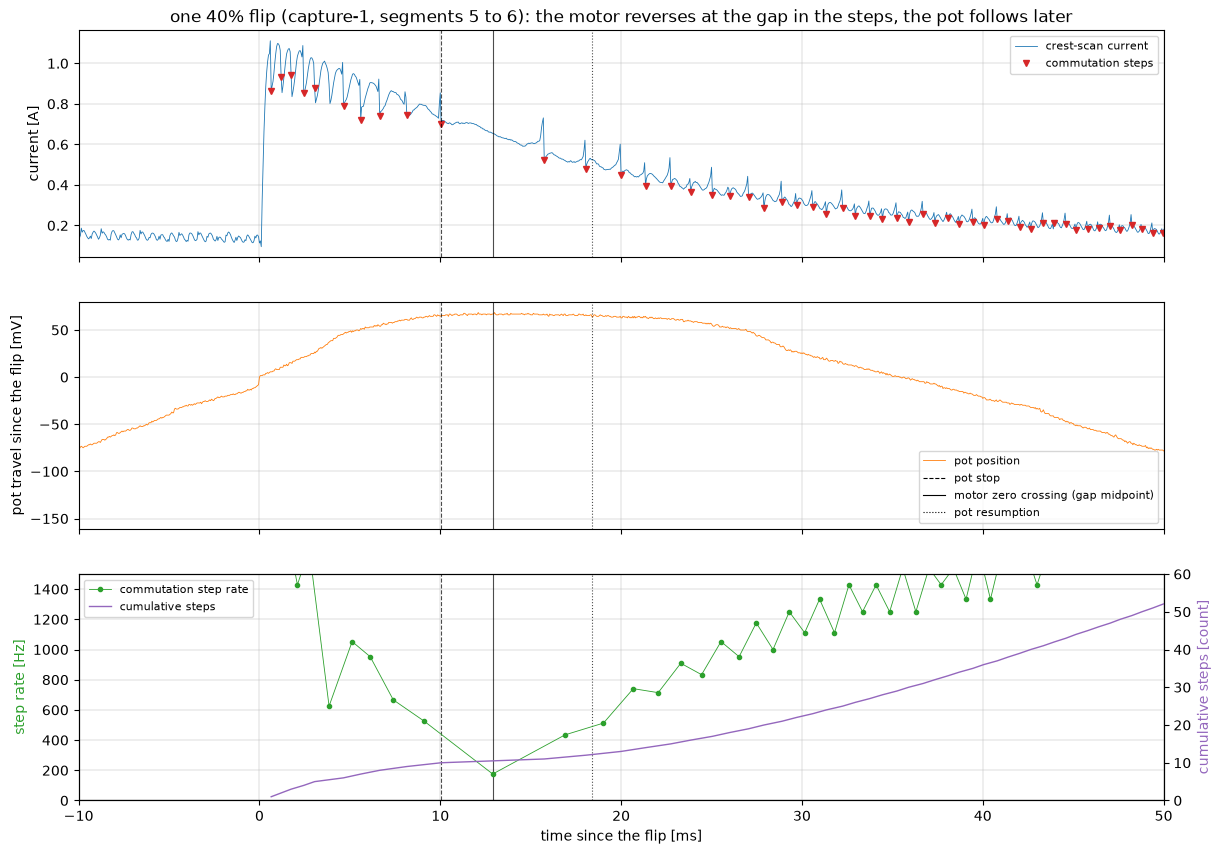

,value
mag_pct,40
old_direction,forward
f_pre_Hz,1825.713736
v_pre_Vps,6.662402
peak_current_A,1.014583
overshoot_mV,78.22998
t_stop_ms,10.05
t_res_ms,18.4
steps_in_dwell_8pct,2
steps_in_dwell,2


In [14]:
def step_events(x, frac=0.10, floor=10, dist=4):
    # Commutation steps: one-sample jumps above a threshold scaled to the local current.
    d1 = np.zeros_like(x)
    d1[1:] = np.diff(x)
    thr = np.maximum(floor, frac * np.abs(medfilt(x, 21)))
    ev = []
    for k in np.where(np.abs(d1) >= thr)[0]:
        if ev and k - ev[-1][0] <= dist:
            if abs(d1[k]) > abs(ev[-1][1]):
                ev[-1] = (k, d1[k])
        else:
            ev.append((k, d1[k]))
    return np.array([e[0] for e in ev], dtype=int)

PLATEAU_COUNTS = 2
EDGE = 10          # samples excluded at both ends of the post-flip segment (inductive rise, segment end)

def analyze_flip(pre, post, C):
    old = np.sign(pre["duty_pct"].iloc[0])
    x = post["current_raw"].to_numpy().astype(float) - post["bias"].iloc[0]
    p = post["pos"].to_numpy().astype(float) * old              # old direction positive
    p0 = np.median(pre["pos"].to_numpy()[-10:]) * old
    ps = np.convolve(p, np.ones(20) / 20, mode="same")
    top = ps[EDGE:-EDGE].max()
    within = np.where(np.abs(ps - top) <= PLATEAU_COUNTS)[0]
    within = within[(within >= EDGE) & (within < len(p) - EDGE)]
    k_stop, k_res = within.min(), within.max()
    f, X = line_spectrum(pre["current_raw"].to_numpy()[-400:].astype(float))
    f_pre, _ = settled_line(f, X)
    out = {
        "mag_pct": int(post["mag_pct"].iloc[0]),
        "old_direction": "forward" if old > 0 else "reverse",
        "f_pre_Hz": f_pre,
        "v_pre_Vps": pot_speed(pre.iloc[-400:]) * old,
        "peak_current_A": np.median(x[EDGE:60]) * board.a_per_count,
        "overshoot_mV": (top - p0) * board.v_adc_per_count * 1e3,
        "t_stop_ms": k_stop * DT * 1e3,
        "t_res_ms": k_res * DT * 1e3,
    }
    for frac, tag in [(0.08, "steps_in_dwell_8pct"), (0.10, "steps_in_dwell"), (0.12, "steps_in_dwell_12pct")]:
        ev = step_events(x, frac=frac)
        ev = ev[(ev >= EDGE) & (ev < len(x) - EDGE)]
        out[tag] = int(np.sum((ev > k_stop) & (ev < k_res)))
        if frac == 0.10:
            te = ev * DT * 1e3
            mid, gap = (te[1:] + te[:-1]) / 2, np.diff(te)
            m = (mid > 3) & (mid < 30)
            g = np.argmax(gap[m])
            out["t_m_ms"] = mid[m][g]
            out["gap_ms"] = gap[m][g]
            near = (te > out["t_res_ms"] - 3) & (te < out["t_res_ms"] + 3)
            out["motor_rate_at_res_Hz"] = near.sum() / 6e-3
            events = ev
    out["dwell_ms"] = out["t_res_ms"] - out["t_stop_ms"]
    out["dwell_travel_mV"] = out["steps_in_dwell"] / C * 1e3
    out["t_stop_minus_t_m_ms"] = out["t_stop_ms"] - out["t_m_ms"]
    # How much of the plateau is the position ADC sitting on a sticky code
    # rather than the mechanism standing still (section 4.1).
    plate = post["pos"].to_numpy()[k_stop:k_res + 1]
    out["dwell_on_sticky_pct"] = float(np.isin(plate, POT_STICKY).mean()) * 100 if len(plate) else 0.0
    return out, events

C_STEADY = C_MEAN
flips = []
for name, (df, meta) in reversal.items():
    for a, b in flip_pairs(meta):
        row, _ = analyze_flip(df[df["seg"] == a], df[df["seg"] == b], C_STEADY)
        row.update({"recording": name, "flip": f"{a}->{b}"})
        flips.append(row)
flips = pd.DataFrame(flips)

name, (df, meta) = next(iter(reversal.items()))
a, b = flip_pairs(meta)[2]
pre, post = df[df["seg"] == a], df[df["seg"] == b]
row, events = analyze_flip(pre, post, C_STEADY)
both = pd.concat([pre.iloc[-400:], post])
n_pre = 400
x = both["current_raw"].to_numpy().astype(float) - both["bias"].iloc[0]
p = both["pos"].to_numpy() * board.v_adc_per_count * 1e3
t = (np.arange(len(both)) - n_pre) * DT * 1e3
te = events * DT * 1e3
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(t, x * board.a_per_count, lw=0.6, color="tab:blue", label="crest-scan current")
axes[0].plot(te, x[events + n_pre] * board.a_per_count, "v", ms=4, color="tab:red", label="commutation steps")
axes[0].set_ylabel("current [A]")
axes[0].legend(fontsize=8, loc="upper right")
axes[1].plot(t, p - p[n_pre], lw=0.6, color="tab:orange", label="pot position")
for key, ls, lab in [("t_stop_ms", "--", "pot stop"), ("t_m_ms", "-", "motor zero crossing (gap midpoint)"), ("t_res_ms", ":", "pot resumption")]:
    for ax in axes:
        ax.axvline(row[key], color="k", lw=0.8, ls=ls, alpha=0.7)
    axes[1].plot([], [], "k", ls=ls, lw=0.8, label=lab)
axes[1].set_ylabel("pot travel since the flip [mV]")
axes[1].legend(fontsize=8, loc="lower right")
mid = (te[1:] + te[:-1]) / 2
axes[2].plot(mid, 1e3 / np.diff(te), "o-", ms=3, lw=0.6, color="tab:green", label="commutation step rate")
axes[2].set_ylabel("step rate [Hz]", color="tab:green")
axes[2].set_xlabel("time since the flip [ms]")
axes[2].set_ylim(0, 1500)
ax2 = axes[2].twinx()
ax2.plot(te, np.arange(1, len(te) + 1), "-", lw=1, color="tab:purple", label="cumulative steps")
ax2.set_ylabel("cumulative steps [count]", color="tab:purple")
ax2.set_ylim(0, 60)
h1, l1 = axes[2].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[2].legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left")
axes[2].set_xlim(-10, 50)
for ax in axes:
    ax.grid(True, lw=0.3)
axes[0].set_title(f"one 40% flip ({name}, segments {a} to {b}): the motor reverses at the gap in the steps, the pot follows later")
plt.show()

pd.DataFrame([row]).T.rename(columns={0: "value"}).round(2)


### 7.2 Play per direction and amplitude

The table pools the ten flips of each direction and amplitude over the five
recordings. Direction is the direction of the drive before the flip.


In [15]:
cols = ["f_pre_Hz", "v_pre_Vps", "peak_current_A", "overshoot_mV", "t_stop_ms", "t_m_ms", "gap_ms",
        "t_stop_minus_t_m_ms", "t_res_ms", "dwell_ms", "steps_in_dwell", "dwell_travel_mV",
        "motor_rate_at_res_Hz", "dwell_on_sticky_pct"]
play = flips.groupby(["mag_pct", "old_direction"])[cols].agg(["mean", "std", "min", "max"]).round(2)
play.T


mag_pct                        20               40         
old_direction             forward reverse  forward  reverse
f_pre_Hz             mean  785.97  781.07  1770.68  1757.32
                     std    12.67    5.78    55.43    47.00
                     min   772.88  773.23  1711.10  1709.31
                     max   802.54  789.12  1825.71  1813.60
v_pre_Vps            mean    3.87    3.85     6.69     6.64
                     std     0.35    0.37     0.19     0.29
                     min     3.15    3.17     6.34     6.18
                     max     4.21    4.24     7.01     7.07
peak_current_A       mean    0.47    0.47     1.00     1.00
                     std     0.01    0.01     0.01     0.01
                     min     0.46    0.46     0.99     0.99
                     max     0.48    0.48     1.02     1.02
overshoot_mV         mean   33.37   35.51    79.02    85.67
                     std     7.76   10.02    17.29    19.98
                     min    25.74   20.87    55.67    56.60
                     max    48.86   57.04   120.77   118.96
t_stop_ms            mean    7.97    7.86    10.97    10.76
                     std     0.60    0.68     0.49     0.34
                     min     6.95    6.60    10.05    10.10
                     max     8.80    9.25    11.60    11.10
t_m_ms               mean   11.83   11.34    13.07    12.28
                     std     1.89    2.05     0.78     1.20
                     min    10.58    8.22    12.52     8.90
                     max    15.75   15.05    15.23    12.85
gap_ms               mean    8.72    7.17     5.73     5.29
                     std     2.69    1.85     1.52     1.47
                     min     5.40    4.75     3.75     3.30
                     max    12.35   10.35     7.90     7.50
t_stop_minus_t_m_ms  mean   -3.86   -3.48    -2.09    -1.53
                     std     1.57    2.27     0.77     1.35
                     min    -6.95   -6.95    -3.62    -2.57
                     max    -2.28    1.03    -0.92     2.15
t_res_ms             mean   21.05   22.47    17.09    21.64
                     std     4.55    4.90     1.31     2.27
                     min    14.90   15.35    15.30    17.65
                     max    25.45   27.15    18.95    24.60
dwell_ms             mean   13.08   14.62     6.12    10.89
                     std     4.53    5.27     1.60     2.47
                     min     7.25    6.10     4.30     6.60
                     max    17.85   19.70     8.35    14.50
steps_in_dwell       mean    2.90    3.70     1.30     4.00
                     std     2.18    2.21     0.95     1.56
                     min     0.00    1.00     0.00     1.00
                     max     6.00    6.00     3.00     6.00
dwell_travel_mV      mean   11.55   14.74     5.18    15.93
                     std     8.70    8.82     3.78     6.23
                     min     0.00    3.98     0.00     3.98
                     max    23.90   23.90    11.95    23.90
motor_rate_at_res_Hz mean  366.67  416.67   416.67   716.67
                     std   153.16  141.64   161.97   176.56
                     min   166.67  166.67   166.67   333.33
                     max   500.00  500.00   666.67   833.33
dwell_on_sticky_pct  mean    0.00    0.00     0.00     0.00
                     std     0.00    0.00     0.00     0.00
                     min     0.00    0.00     0.00     0.00
                     max     0.00    0.00     0.00     0.00

In [16]:
sens = flips.groupby(["mag_pct", "old_direction"])[["steps_in_dwell_8pct", "steps_in_dwell", "steps_in_dwell_12pct"]].mean()
sens["dwell_travel_mV_8pct"] = sens["steps_in_dwell_8pct"] / C_STEADY * 1e3
sens["dwell_travel_mV_12pct"] = sens["steps_in_dwell_12pct"] / C_STEADY * 1e3
sens["median_steps"] = flips.groupby(["mag_pct", "old_direction"])["steps_in_dwell"].median()
sens["flips"] = flips.groupby(["mag_pct", "old_direction"]).size()
allrow = pd.Series({
    "steps_in_dwell_8pct": flips["steps_in_dwell_8pct"].mean(), "steps_in_dwell": flips["steps_in_dwell"].mean(),
    "steps_in_dwell_12pct": flips["steps_in_dwell_12pct"].mean(),
    "dwell_travel_mV_8pct": flips["steps_in_dwell_8pct"].mean() / C_STEADY * 1e3,
    "dwell_travel_mV_12pct": flips["steps_in_dwell_12pct"].mean() / C_STEADY * 1e3,
    "median_steps": flips["steps_in_dwell"].median(), "flips": len(flips)}, name=("all", "all"))
sens = pd.concat([sens, allrow.to_frame().T])
sens["dwell_travel_mV"] = sens["steps_in_dwell"] / C_STEADY * 1e3
sens.round(2)


steps_in_dwell_8pct  steps_in_dwell  steps_in_dwell_12pct  dwell_travel_mV_8pct  dwell_travel_mV_12pct  median_steps  flips  dwell_travel_mV
20  forward                 3.20            2.90                   2.7                 12.75                  10.75           3.0   10.0            11.55
    reverse                 3.70            3.70                   3.7                 14.74                  14.74           4.5   10.0            14.74
40  forward                 1.30            1.30                   1.3                  5.18                   5.18           1.0   10.0             5.18
    reverse                 4.10            4.00                   3.9                 16.33                  15.53           4.0   10.0            15.93
all all                     3.08            2.98                   2.9                 12.25                  11.55           3.0   40.0            11.85

### 7.3 Slip signatures

Slip would show as motor cycles that the pot never sees outside a
reversal. Two tests cover it. Inside the steady steps, a slipped tooth
would shift the residual of section 6.1 by one cycle's worth of wiper
travel, 4 mV, at a position that differs from recording to recording.
The between-trace rms of section 6.2 already bounds that. The table
below adds, per group, the largest deviation of any single trace from the
group's mean pattern, in cycles. The second test looks for the pot
standing still while the motor turns, outside the reversal dwell. Within
every accepted trace, every run of at least 2 ms in which the 1 ms
smoothed pot stays within two counts is listed with the motor cycles it
contains, and the minimum local gain of section 6.2 gives the same test
in position bins.


In [17]:
def group_max_dev(g):
    lo = g.groupby(["recording", "seg"])["p"].min().max() + 0.01
    hi = g.groupby(["recording", "seg"])["p"].max().min() - 0.01
    if hi - lo < 0.1:
        return None
    gridp = np.arange(lo, hi, 0.002)
    curves = []
    for (rec, sid), t in g.groupby(["recording", "seg"]):
        order = np.argsort(t["p"].to_numpy())
        c = np.interp(gridp, t["p"].to_numpy()[order], t["res"].to_numpy()[order])
        curves.append(c - np.polyval(np.polyfit(gridp, c, 1), gridp))
    curves = np.array(curves)
    dev = np.abs(curves - curves.mean(axis=0)).max()
    return {"traces": len(curves), "max_single_trace_deviation_mV": dev * 1e3,
            "in_cycles": dev * C_MEAN}

rows = []
for (camp, mag, dname), g in traces.groupby(["campaign", "mag_pct", "direction"]):
    r = group_max_dev(g)
    if r:
        rows.append({"campaign": camp, "mag_pct": mag, "direction": dname, **r})
slip_a = pd.DataFrame(rows).set_index(["campaign", "mag_pct", "direction"])

# Pot standstills inside accepted traces.
stalls = []
for (camp, rec, sid), g in traces.groupby(["campaign", "recording", "seg"]):
    p = g["p"].to_numpy() / board.v_adc_per_count
    th = g["theta"].to_numpy()
    ps = np.convolve(p, np.ones(20) / 20, mode="same")
    moving = np.abs(np.gradient(ps)) * 40 > PLATEAU_COUNTS     # more than 2 counts per 2 ms
    still = ~moving
    still[:10] = still[-10:] = False
    edges = np.diff(still.astype(int))
    starts, ends = np.where(edges == 1)[0] + 1, np.where(edges == -1)[0] + 1
    for s, e in zip(starts, ends):
        if e - s >= 40:
            codes = np.round(p[s:e]).astype(int)
            stalls.append({"campaign": camp, "recording": rec, "seg": sid, "mag_pct": g["mag_pct"].iloc[0],
                           "position_V": g["p"].iloc[s], "duration_ms": (e - s) * DT * 1e3,
                           "motor_cycles": th[e] - th[s],
                           "on_sticky_pct": float(np.isin(codes, POT_STICKY).mean()) * 100})
stalls = pd.DataFrame(stalls)
slip_b = pd.DataFrame([{
    "accepted traces": traces.groupby(["campaign", "recording", "seg"]).ngroups,
    "standstills of 2 ms or more": len(stalls),
    "longest standstill [ms]": stalls["duration_ms"].max() if len(stalls) else 0.0,
    "most motor cycles in a standstill": stalls["motor_cycles"].abs().max() if len(stalls) else 0.0,
    # how many of those standstills are the position ADC and not the mechanism
    "standstills more than half on a sticky code [%]":
        float((stalls["on_sticky_pct"] > 50).mean()) * 100 if len(stalls) else 0.0,
    "median share of a standstill on a sticky code [%]":
        stalls["on_sticky_pct"].median() if len(stalls) else 0.0,
    "minimum local gain [mV per cycle]": gmap["mean"].min(),
    "maximum local gain [mV per cycle]": gmap["mean"].max(),
    "largest single-trace deviation [cycles]": slip_a["in_cycles"].max(),
}]).T.rename(columns={0: "value"})
slip_b.round(3)


,value
accepted traces,146.000
standstills of 2 ms or more,1.000
longest standstill [ms],2.000
most motor cycles in a standstill,1.298
standstills more than half on a sticky code [%],0.000
median share of a standstill on a sticky code [%],0.000
minimum local gain [mV per cycle],1.145
maximum local gain [mV per cycle],6.624
largest single-trace deviation [cycles],2.607


Findings for section 7:

- **Braking.** After a flip the drive current jumps to 0.47 A at 20% and
  1.00 A at 40%. The output keeps moving in the old direction and covers
  33 to 36 mV at 20% and 79 to 86 mV at 40% before it stops, with no flip
  reporting less than 21 mV: the zero-overshoot readings of the 48 MHz
  session, which were the position reading never leaving the code it was
  already on, are gone.
- **The motor reverses after the output stops, by 1.5 to 3.9 ms.** The gap
  in the commutation steps is centred 11.3 to 13.1 ms after the flip with a
  standard deviation of 0.8 to 2.1 ms, and the pot's plateau starts 7.9 to
  11.0 ms after it. The ordering is the mechanically sensible one: the
  output stops first, the motor keeps turning into the play, then it
  reverses. The gap itself is 5.3 to 8.7 ms wide.
- **The play is 3.0 commutation steps, 11.9 mV of wiper.** Over the forty
  flips the motor makes 2.98 steps inside the pot's plateau on average,
  median 3.0, a dwell travel of 11.85 mV of wiper mean and 11.95 mV median.
  In output terms, using the pot scale of section 5.4, that is 14.7 counts,
  0.76 degrees of output shaft.
- **The threshold check holds.** Moving the step detector from 8% to 12% of
  the local current takes the count from 3.08 to 2.90 steps per flip, 12.25
  to 11.55 mV, a 6% change in the answer. On the 48 MHz session the same
  sweep moved it by a third. At these larger flip currents the steps are
  unambiguous.
- **The play is direction-asymmetric, and that is the interesting part.**
  A flip out of a forward drive at 40% gives 1.3 steps, 5.2 mV; out of a
  reverse drive at 40% it gives 4.0 steps, 15.9 mV. At 20% the two are 2.9
  and 3.7 steps. The asymmetry has the same sign as the 2% forward-reverse
  difference in the coupling of section 5, which is what a fixed amount of
  play does to a cycle count that starts at a direction change.
  *Hypothesis (not tested here): the two directions load different flanks of
  the same four meshes, and the flank clearances are not equal. A flip at a
  third amplitude and a flip after a dwell at zero drive would separate a
  clearance from an elastic wind-up in the train.*
- **Nothing slips.** In the 146 accepted traces of the steady steps and the
  grid there is exactly one interval of 2 ms or longer where the pot stands
  still while the motor turns, and it is worth 1.3 motor cycles, 5 mV, which
  is inside the pot's own gain minimum. None of it is on a sticky code. The
  largest deviation of any single trace from its group's pattern is 2.6
  cycles, 10 mV. So no tooth in this train skips outside a reversal, at the
  duties and loads this campaign covers.


## 8. Limitations and open issues

- **The bus couples into the current channel.** Section 5.1 measures the
  1250 Hz line and its harmonics against the ripple line and finds the
  ripple at least 3.0 times taller in the worst single step, at 60% duty
  where the artifact is largest and the line weakest. At 20% and 40% the
  margin is 35 to 47 times. At a higher duty still, or with a weaker
  ripple, the artifact would be inside the search band with nothing keeping
  it out. This is a limitation of this board, not something I code around.
- **The sub-line family overtakes the line at 60% duty.** The peak at one
  third of the line frequency averages 1.16 times the line there. The
  settled-line rule does not always recover from that, and the tracker only
  survives it because it seeds from the pot speed rather than from the
  largest peak. Above 60% duty nothing in this notebook has been shown to
  track, and the grid is taken only to 55% for that reason.
- **The tracker's floor.** The tracker needs the line above 250 Hz, about
  1 wiper V/s, inside a 10 ms window, and it needs 0.15 V of travel before
  a step counts. Two of the ten 60% forward steady steps and two grid steps
  fall out on those tests. Below about 15% duty the tachometer does not
  exist.
- **The pot scale rests on two counted inputs.** Section 5.4 converts cycles
  per wiper volt into counts per degree using the counted gear ratio and the
  counted six pulses per revolution. Both are parts counts rather than fits,
  and the six is cross-checked against an optical tachometer, but a close
  pair of commutation pulses per line cycle would halve the pulse count and
  the pot scale with it. Nothing else in this notebook depends on either.
- **Position coverage and where the map is thin.** The gain map covers 0.32
  to 2.96 wiper V without a gap, which is essentially the whole 10 to 170
  degree envelope, but the outermost 0.25 V bands rest on 40 traces per bin
  against 120 to 140 in the middle, and they hold both extremes of the local
  gain. The 1.15 mV per cycle minimum at 0.32 V is one bin at the edge of
  travel where every step is starting or stopping.
- **One unit, one gear train.** All numbers describe this one servo, on a
  board that was reworked by hand. The gear train has prior wear and has
  been serviced after a run of end-stop crashes.
- **Voltages are nominal-referenced.** Every current and every wiper volt
  scales with the true VDD of this unit (section 2). Cycles per wiper volt
  scale inversely with it, and so does the counts-per-degree of section 5.4.
- **The play is measured at two amplitudes and one temperature.** The
  direction asymmetry of section 7.2 is larger than the amplitude
  dependence, and neither is mapped.


## 9. What later notebooks use from here

The table collects what this notebook measured. Everything in it is a
measurement on this dataset except the two rows marked as a cross-check,
which combine this notebook's coupling with the back-EMF constants measured
elsewhere and disagree by 6%; section 10 takes that up.


In [18]:
KE = servo.measured["ke_measured"]       # mV per motor rev/s, ripple speed + coast BEMF
K_E_WIPER = 0.289                        # V per wiper V/s, nb05 on this dataset
OK = "measured"
CHECK = "cross-check, section 10"

handoff = pd.DataFrame([
    {"quantity": "coupling C, travel-weighted, both campaigns", "value": C_MEAN, "unit": "ripple cycles per wiper V", "status": OK},
    {"quantity": "coupling C, steady steps 40% and 60%", "value": pooled.loc["steady steps, 40% and 60%", "travel_weighted"], "unit": "ripple cycles per wiper V", "status": OK},
    {"quantity": "coupling C, duty grid 30 to 45%", "value": scale.loc["2S duty grid, 30 to 45%", "C travel weighted"], "unit": "ripple cycles per wiper V", "status": OK},
    {"quantity": "wiper travel per ripple cycle", "value": 1e3 / C_MEAN, "unit": "mV", "status": OK},
    {"quantity": "wiper travel per motor revolution", "value": 1e3 / C_MEAN * PULSES.value, "unit": "mV", "status": OK},
    {"quantity": "pot scale from the counted gear ratio, grid 30 to 45%", "value": scale.loc["2S duty grid, 30 to 45%", "pot scale [counts per deg]"], "unit": "counts per deg", "status": OK},
    {"quantity": "pot scale from the counted gear ratio, both campaigns", "value": scale.loc["2S both campaigns", "pot scale [counts per deg]"], "unit": "counts per deg", "status": OK},
    {"quantity": "ripple line amplitude, 20 to 60% duty", "value": lines["amp_mA"].mean(), "unit": "mA", "status": OK},
    {"quantity": "ripple line over the board's 1250 Hz bus line", "value": bus["ripple over bus"].min(), "unit": "times, worst step", "status": OK},
    {"quantity": "local gain in 20 mV bins, minimum", "value": gmap["mean"].min(), "unit": "mV per cycle", "status": OK},
    {"quantity": "local gain in 20 mV bins, maximum", "value": gmap["mean"].max(), "unit": "mV per cycle", "status": OK},
    {"quantity": "local gain swing, max over min", "value": gmap["mean"].max() / gmap["mean"].min(), "unit": "times", "status": OK},
    {"quantity": "pooled pattern, peak to peak", "value": (pattern.max() - pattern.min()) * 1e3, "unit": "mV", "status": OK},
    {"quantity": "pooled pattern, maxima spacing", "value": spacing.mean(), "unit": "wiper V", "status": OK},
    {"quantity": "pattern repeatability between recordings", "value": repro["between_trace_rms_mV"].mean(), "unit": "mV rms", "status": OK},
    {"quantity": "play, all flips, mean dwell travel", "value": flips["dwell_travel_mV"].mean(), "unit": "mV of wiper", "status": OK},
    {"quantity": "play, all flips, median dwell travel", "value": flips["dwell_travel_mV"].median(), "unit": "mV of wiper", "status": OK},
    {"quantity": "braking distance at 20%, mean", "value": flips[flips["mag_pct"] == 20]["overshoot_mV"].mean(), "unit": "mV of wiper", "status": OK},
    {"quantity": "braking distance at 40%, mean", "value": flips[flips["mag_pct"] == 40]["overshoot_mV"].mean(), "unit": "mV of wiper", "status": OK},
    {"quantity": "motor reversal time after a flip, mean", "value": flips["t_m_ms"].mean(), "unit": "ms", "status": OK},
    {"quantity": "back-EMF per ripple cycle per second, from the servo entry Ke", "value": KE.value / PULSES.value, "unit": "mV per Hz", "status": OK},
    {"quantity": "back-EMF per ripple cycle per second, from nb05 k_e and C", "value": K_E_WIPER / C_MEAN * 1e3, "unit": "mV per Hz", "status": CHECK},
    {"quantity": "coupling C implied by those two BEMF routes", "value": K_E_WIPER / (KE.value / PULSES.value) * 1e3, "unit": "ripple cycles per wiper V", "status": CHECK},
    {"quantity": "back-EMF constant at the motor shaft, from the servo entry Ke", "value": KE.value / (2 * np.pi), "unit": "mV per rad/s", "status": OK},
]).set_index("quantity")
handoff.round(3)


,value,unit,status
quantity,,,
"coupling C, travel-weighted, both campaigns",251.054,ripple cycles per wiper V,measured
"coupling C, steady steps 40% and 60%",250.627,ripple cycles per wiper V,measured
"coupling C, duty grid 30 to 45%",251.653,ripple cycles per wiper V,measured
wiper travel per ripple cycle,3.983,mV,measured
wiper travel per motor revolution,23.899,mV,measured
"pot scale from the counted gear ratio, grid 30 to 45%",19.296,counts per deg,measured
"pot scale from the counted gear ratio, both campaigns",19.342,counts per deg,measured
"ripple line amplitude, 20 to 60% duty",10.920,mA,measured
ripple line over the board's 1250 Hz bus line,3.028,"times, worst step",measured


- The ripple tachometer of section 5. The crest-scan current carries a
  line at $C$ times the wiper speed, 251.1 cycles per wiper volt, with an
  amplitude of 8 to 12 mA, and the tracker of section 5.2 turns it into a
  motor-side angle from about 1 wiper V/s upward, exact to a fraction of a
  cycle. The brake-window sample carries no line. The number holds to 0.5%
  within the grid's 30 to 45% band and to 0.6% against the USB captures.
- The pot scale that follows from it and the counted gear ratio, 19.34
  counts per degree of output shaft. That is 3.1% below the 19.96 the servo
  entry declares from eyeballed horn angles and 5.7% above the 18.29 it
  carries as measured. This notebook does not settle which is right, and
  section 10 says what would.
- **The pot's local gain is not constant.** It swings from 1.1 to 6.6 mV
  per ripple cycle as a repeatable function of position, with a pattern
  54 mV peak to peak whose maxima sit 0.17 wiper V apart, reproducible
  between captures to 1.3 mV rms. Any speed or acceleration differentiated
  from the pot carries that swing as a multiplicative error of roughly plus
  or minus a third, which is notebook 01's unexplained speed ripple. A
  velocity estimator that wants better than that needs either the ripple
  line or the back-EMF, or a per-position correction table built from a map
  like this one.
- The gear play, 3.0 commutation steps per reversal, 11.9 mV of wiper,
  0.76 degrees of output, direction-asymmetric by a factor of three at
  40% duty. The commutation steps stop for 5 to 9 ms around the reversal
  and the gap centre sits 11 to 13 ms after the flip, at a flip current of
  0.47 A at 20% duty and 1.00 A at 40%. The output stops 1.5 to 3.9 ms
  before the motor reverses.
- The finding that nothing slips outside a reversal: one standstill worth
  1.3 motor cycles in 146 accepted traces.
- The back-EMF per ripple cycle per second, 1.23 mV per Hz from the servo
  entry's own Ke, and a back-EMF constant at the motor shaft of 1.17 mV per
  rad/s. Both scale with the true VDD of this unit.


## 10. Open discrepancies

Four numbers in this notebook do not line up with numbers measured
elsewhere on the same servo. Each gets its candidate causes and the
experiment that would tell them apart.

**1. The coupling is 251.1 cycles per wiper volt here and 265.5 in the
servo entry.** The entry's `pot_scale` of 18.29 counts per degree is that
same measurement expressed through the counted gear ratio, from the 2S grid
rungs at 30 to 45% duty, which is exactly the population section 5.4 reads
at 251.7. The gap is 5.5%, and it is the difference between 18.29 and 19.30
counts per degree. Candidates: (a) a different estimator, since this
notebook's own two estimators differ by 3% on the same steps, the
demodulated cycles over travel giving 251 and the settled-window ratio
$f/v$ giving 259; (b) a different position weighting, which matters because
section 6 shows the local gain swings 5.8-fold, so any $C$ is an average of
that swing weighted by where the steps ran and how far; (c) an error in one
of the two pipelines.
*Discriminator:* run both estimators over one identical set of steps and one
identical position band. If they converge, it is (a) and the weighting rule
should be stated with the number. If they do not, the tie-breaker is not
another ripple measurement at all: put an absolute angle reference on the
output shaft, a dial indicator or an indexed horn over the full envelope,
and read counts per degree directly. Both routes ultimately want that, and
neither has it. Note which way the error would push a control loop: 5.5% on
the pot scale is 5.5% on every commanded angle.

**2. The back-EMF route to the coupling gives 235, not 251.** Notebook 05
measures 0.289 V of coast EMF per wiper V/s on this dataset, and the servo
entry carries 7.367 mV per motor rev/s measured from ripple speed and coast
EMF together. Their ratio is a coupling, 235.4 cycles per wiper volt, 6.3%
below the ripple route here. Candidates: the two are weighted over different
positions, since the spin-down coasts sit wherever the previous step left
them while the grid rungs cover two thirds of travel; the entry's own note
says its Ke reads slightly high because the drive ripple averages a speed
that is still rising while the coast EMF is near final speed, and a high Ke
pushes this implied coupling low; or notebook 05's slope carries the play of
section 7 inside the pot travel it calibrates against.
*Discriminator:* measure both in the same coast segments, taking the ripple
line and the terminal EMF from the same milliseconds of the same spindown,
and form the ratio per segment. That removes the position weighting and the
campaign difference at once, and it is a re-analysis of captures that
already exist.

**3. The pattern's period matches no gear.** The pooled pattern's maxima sit
0.17 wiper V apart, which is 42.7 ripple cycles, 7.1 motor revolutions, and
about 33 periods per revolution of the output shaft. The three intermediate
stages turn 3.3, 13.1 and 49.9 times per output revolution, so none of them
is 33. Candidates: the pot element's own periodicity, a wound or printed
track having structure of its own; the wiper contact rather than the track;
a beat between a stage frequency and the 20 mV binning of the map; or the
peak finder counting harmonics of a longer fundamental as separate maxima.
*Discriminator:* take the spectrum of the residual against wiper position
rather than counting peaks, over the whole envelope, with 3.3, 13.1 and 49.9
per revolution marked on it. If a stage frequency carries the power, it is
gear runout. Then repeat one rung at half the duty: a mechanical error stays
fixed in position, a sampling or binning artifact moves with speed.

**4. At 60% duty the once-per-revolution sub-lines outgrow the commutation
line.** The peak at $f_r/3$ averages 1.16 times the line at 60% duty against
0.05 at 20%. Candidates: brush bounce growing with speed, so the six
commutation events of a revolution become progressively unequal; a
commutator or armature asymmetry whose electrical effect scales with speed;
or something in the measurement, since the bus artifact also grows with
current and sits at 1250 Hz, close to the 1063 Hz where the $f_r/3$ line
lands at 60% duty.
*Discriminator:* the bus artifact is fixed at 1250 Hz and the sub-line
tracks speed, so run a duty between 55% and 60% and watch which one moves.
The optical tachometer that already confirmed the six pulses per revolution
would settle the mechanical half directly: a once-per-revolution modulation
visible on the tach is the motor, one visible only in the shunt current is
the measurement.
